In [3]:
import io, os, re, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.svm import LinearSVR, SVR
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path

import xgboost as xgb
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)



In [4]:

# GOOGLE DRIVE MOUNT (ONLY FOR COLAB)

if os.path.exists("/content"):
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except:
        pass


# PATH CONFIGURATION

if os.path.exists("/content/drive"):
    BASE_PATH = Path("/content/drive/MyDrive/uk-energy-grid")
else:
    BASE_PATH = Path(".")

DATA_PATH = BASE_PATH / "data" / "integrated_data" / "GB_master_2020_2025.csv"

RESULTS_DIR = BASE_PATH / "results" / "metrics"
FIGURES_DIR = BASE_PATH / "results" / "figures"


# CREATE DIRECTORIES

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)



# VALIDATION

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")


# PRINT PATH INFO

print("Environment:", "Colab" if os.path.exists("/content/drive") else "Local")
print("Base path:", BASE_PATH)
print("Dataset path:", DATA_PATH.resolve())
print("Results directory:", RESULTS_DIR.resolve())
print("Figures directory:", FIGURES_DIR.resolve())





Mounted at /content/drive
Environment: Colab
Base path: /content/drive/MyDrive/uk-energy-grid
Dataset path: /content/drive/MyDrive/uk-energy-grid/data/integrated_data/GB_master_2020_2025.csv
Results directory: /content/drive/MyDrive/uk-energy-grid/results/metrics
Figures directory: /content/drive/MyDrive/uk-energy-grid/results/figures


In [5]:
# LOAD DATA

df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully")
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully
Shape: (100800, 58)


,DATETIME,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,OTHER,SOLAR,STORAGE,GENERATION,CARBON_INTENSITY,freq_mean,freq_min,freq_max,freq_std,out_of_49_5_50_5,out_of_49_8_50_2,n_points,Temperature (°C)_aberdeen,Precipitation (mm)_aberdeen,Wind Speed (m/s)_aberdeen,Wind Direction (deg)_aberdeen,Solar Irradiance (W/m²)_aberdeen,Cloud Cover (%)_aberdeen,Temperature (°C)_humber,Precipitation (mm)_humber,Wind Speed (m/s)_humber,Wind Direction (deg)_humber,Solar Irradiance (W/m²)_humber,Cloud Cover (%)_humber,Temperature (°C)_camborne,Precipitation (mm)_camborne,Wind Speed (m/s)_camborne,Wind Direction (deg)_camborne,Solar Irradiance (W/m²)_camborne,Cloud Cover (%)_camborne,Temperature (°C)_ashford,Precipitation (mm)_ashford,Wind Speed (m/s)_ashford,Wind Direction (deg)_ashford,Solar Irradiance (W/m²)_ashford,Cloud Cover (%)_ashford,Temperature (°C)_eastanglia,Precipitation (mm)_eastanglia,Wind Speed (m/s)_eastanglia,Wind Direction (deg)_eastanglia,Solar Irradiance (W/m²)_eastanglia,Cloud Cover (%)_eastanglia,Day,Holiday,ND,TSD,SETTLEMENT_DATE,SETTLEMENT_PERIOD,Datetime_utc
0,2020-01-01 00:00:00+00:00,7915,670,6953,5004,1135,672,2993,2353,130,0,41,27866,162,50.0567,49.968,50.119,0.0389,0,0,1800,3.6,0.0,18.5,201.0,0.0,41.0,3.8,0.0,12.3,148.0,0.0,54.0,7.8,0.0,10.5,98.0,0.0,100.0,3.6,0.0,10.9,136.0,0.0,17.0,7.5,0.0,12.9,113.0,0.0,100.0,Wednesday,Yes,26340.0,27153.0,01-Jan-20,1,2020-01-01 00:00:00+00:00
1,2020-01-01 00:30:00+00:00,8423,670,6949,5043,1096,669,2944,2358,123,0,62,28337,166,50.0079,49.947,50.109,0.0325,0,0,1800,3.6,0.0,18.5,201.0,0.0,41.0,3.8,0.0,12.3,148.0,0.0,54.0,7.8,0.0,10.5,98.0,0.0,100.0,3.6,0.0,10.9,136.0,0.0,17.0,7.5,0.0,12.9,113.0,0.0,100.0,Wednesday,Yes,26921.0,27684.0,01-Jan-20,2,2020-01-01 00:30:00+00:00
2,2020-01-01 01:00:00+00:00,8040,670,6952,5030,1059,662,2894,2356,122,0,0,27786,164,49.9854,49.892,50.046,0.0471,0,0,1800,3.6,0.0,18.7,208.0,0.0,38.0,3.8,0.0,9.6,146.0,0.0,100.0,7.4,0.0,9.9,109.0,0.0,67.0,2.8,0.0,8.2,128.0,0.0,22.0,7.2,0.0,12.2,124.0,0.0,100.0,Wednesday,Yes,26569.0,27240.0,01-Jan-20,3,2020-01-01 01:00:00+00:00
3,2020-01-01 01:30:00+00:00,7502,670,6948,4825,1026,591,2847,2343,122,0,0,26874,161,49.9540,49.897,50.048,0.0344,0,0,1800,3.6,0.0,18.7,208.0,0.0,38.0,3.8,0.0,9.6,146.0,0.0,100.0,7.4,0.0,9.9,109.0,0.0,67.0,2.8,0.0,8.2,128.0,0.0,22.0,7.2,0.0,12.2,124.0,0.0,100.0,Wednesday,Yes,25754.0,26435.0,01-Jan-20,4,2020-01-01 01:30:00+00:00
4,2020-01-01 02:00:00+00:00,7023,669,6954,4689,999,548,2789,2356,121,0,0,26148,158,50.0075,49.925,50.125,0.0596,0,0,1800,3.4,0.0,14.5,210.0,0.0,29.0,4.1,0.0,9.2,141.0,0.0,100.0,7.0,0.0,7.3,110.0,0.0,100.0,2.8,0.0,8.5,118.0,0.0,90.0,6.9,0.0,12.6,143.0,0.0,94.0,Wednesday,Yes,25075.0,25824.0,01-Jan-20,5,2020-01-01 02:00:00+00:00


## Data Quality Assessment
Covers:
- Column dtypes
- Duplicate DATETIME rows
- Missing 30-minute timestamps (gaps)
- Numeric summary statistics
- Missing values by column

In [6]:
# Parse & sort by DATETIME

df1 = df.copy()
df1["DATETIME"] = pd.to_datetime(df1["DATETIME"], utc=True, errors="coerce")
df1 = df1.sort_values("DATETIME").reset_index(drop=True)

print("✅ Columns and dtypes:")
print(df1.dtypes)


✅ Columns and dtypes:
DATETIME                              datetime64[ns, UTC]
GAS                                                 int64
COAL                                                int64
NUCLEAR                                             int64
WIND                                                int64
WIND_EMB                                            int64
HYDRO                                               int64
IMPORTS                                             int64
BIOMASS                                             int64
OTHER                                               int64
SOLAR                                               int64
STORAGE                                             int64
GENERATION                                          int64
CARBON_INTENSITY                                    int64
freq_mean                                         float64
freq_min                                          float64
freq_max                                          

In [7]:
# Duplicate timestamps
dups = df1[df1.duplicated(subset=["DATETIME"], keep=False)].sort_values("DATETIME")
print(f"Duplicate timestamp rows: {len(dups)}")
if len(dups) > 0:
    display(dups.head(10))


Duplicate timestamp rows: 0


In [8]:
#  Gap analysis: expected 30-min slots vs present
start, end = df1["DATETIME"].min(), df1["DATETIME"].max()
expected_index = pd.date_range(start, end, freq="30min", tz="UTC")
present_index  = pd.to_datetime(df1["DATETIME"].dropna(), utc=True)
missing_ts     = expected_index.difference(present_index)

print(f"Time range     : {start} → {end}")
print(f"Expected slots : {len(expected_index)}")
print(f"Present rows   : {len(df1)}")
print(f"Missing slots  : {len(missing_ts)}")

if len(missing_ts) > 0:
    display(pd.DataFrame({"missing_datetime_utc": missing_ts}).head(20))


Time range     : 2020-01-01 00:00:00+00:00 → 2025-09-30 23:30:00+00:00
Expected slots : 100800
Present rows   : 100800
Missing slots  : 0


In [9]:
# Numeric summary
num_cols = df1.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric column summary:")
display(df1[num_cols].describe().T.round(3))


Numeric column summary:


,count,mean,std,min,25%,50%,75%,max
GAS,100800.0,10498.007,5632.382,42.000,5552.750,9923.000,14769.000,27868.000
COAL,100800.0,356.460,587.726,0.000,0.000,0.000,499.000,4392.000
NUCLEAR,100800.0,4730.298,866.137,2065.000,4189.000,4717.000,5265.000,6986.000
WIND,100800.0,6754.846,4080.640,0.000,3288.000,6192.000,10010.000,17406.000
WIND_EMB,100800.0,1711.258,1073.420,125.000,858.000,1450.000,2355.000,5947.000
HYDRO,100800.0,393.203,245.157,0.000,185.000,356.000,562.000,1181.000
IMPORTS,100800.0,3560.569,1996.890,0.000,2044.000,3494.000,4964.000,9148.000
BIOMASS,100800.0,1957.687,757.549,0.000,1371.000,2022.000,2508.250,3368.000
OTHER,100800.0,300.419,251.874,0.000,149.000,203.000,354.000,3036.000
SOLAR,100800.0,1616.699,2514.733,0.000,0.000,11.000,2620.000,14035.000


In [10]:
# Missing values per column
print("Missing values by column:")
na_counts = df1.isna().sum().sort_values(ascending=False)
display(na_counts.head(40))

rows_with_na = df1[df1.isna().any(axis=1)]
print(f"\nRows containing any missing values: {len(rows_with_na)}")
display(rows_with_na.head(10))


Missing values by column:


,0
TSD,722
ND,722
COAL,0
NUCLEAR,0
WIND,0
WIND_EMB,0
HYDRO,0
IMPORTS,0
DATETIME,0
GAS,0



Rows containing any missing values: 722


,DATETIME,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,OTHER,SOLAR,STORAGE,GENERATION,CARBON_INTENSITY,freq_mean,freq_min,freq_max,freq_std,out_of_49_5_50_5,out_of_49_8_50_2,n_points,Temperature (°C)_aberdeen,Precipitation (mm)_aberdeen,Wind Speed (m/s)_aberdeen,Wind Direction (deg)_aberdeen,Solar Irradiance (W/m²)_aberdeen,Cloud Cover (%)_aberdeen,Temperature (°C)_humber,Precipitation (mm)_humber,Wind Speed (m/s)_humber,Wind Direction (deg)_humber,Solar Irradiance (W/m²)_humber,Cloud Cover (%)_humber,Temperature (°C)_camborne,Precipitation (mm)_camborne,Wind Speed (m/s)_camborne,Wind Direction (deg)_camborne,Solar Irradiance (W/m²)_camborne,Cloud Cover (%)_camborne,Temperature (°C)_ashford,Precipitation (mm)_ashford,Wind Speed (m/s)_ashford,Wind Direction (deg)_ashford,Solar Irradiance (W/m²)_ashford,Cloud Cover (%)_ashford,Temperature (°C)_eastanglia,Precipitation (mm)_eastanglia,Wind Speed (m/s)_eastanglia,Wind Direction (deg)_eastanglia,Solar Irradiance (W/m²)_eastanglia,Cloud Cover (%)_eastanglia,Day,Holiday,ND,TSD,SETTLEMENT_DATE,SETTLEMENT_PERIOD,Datetime_utc
100078,2025-09-15 23:00:00+00:00,3109,0,2493,14380,4205,357,896,1179,599,0,0,27218,57,50.0658,49.910,50.157,0.0735,0,0,1800,12.2,0.0,19.3,321.0,0.0,92.0,13.5,0.0,24.8,256.0,0.0,62.0,13.7,0.0,28.4,275.0,0.0,39.0,13.3,0.0,28.9,255.0,0.0,4.0,13.9,0.0,30.2,250.0,0.0,22.0,Tuesday,No,NaN,NaN,16-Sep-25,1,2025-09-15 23:00:00+00:00
100079,2025-09-15 23:30:00+00:00,3067,0,2497,14526,4213,357,838,1151,347,0,0,26996,54,50.1176,50.034,50.169,0.0290,0,0,1800,12.2,0.0,19.3,321.0,0.0,92.0,13.5,0.0,24.8,256.0,0.0,62.0,13.7,0.0,28.4,275.0,0.0,39.0,13.3,0.0,28.9,255.0,0.0,4.0,13.9,0.0,30.2,250.0,0.0,22.0,Tuesday,No,NaN,NaN,16-Sep-25,2,2025-09-15 23:30:00+00:00
100080,2025-09-16 00:00:00+00:00,3108,0,2495,14642,4228,357,244,1169,764,0,0,27007,59,49.8935,49.850,50.112,0.0344,0,0,1800,11.9,0.0,19.7,318.0,0.0,93.0,13.5,0.0,23.9,256.0,0.0,100.0,13.4,0.0,27.7,273.0,0.0,69.0,13.1,0.0,27.7,254.0,0.0,1.0,13.6,0.0,28.7,251.0,0.0,20.0,Tuesday,No,NaN,NaN,16-Sep-25,3,2025-09-16 00:00:00+00:00
100081,2025-09-16 00:30:00+00:00,3173,0,2496,14732,4163,355,236,1163,677,0,0,26995,59,50.0496,49.939,50.125,0.0526,0,0,1800,11.9,0.0,19.7,318.0,0.0,93.0,13.5,0.0,23.9,256.0,0.0,100.0,13.4,0.0,27.7,273.0,0.0,69.0,13.1,0.0,27.7,254.0,0.0,1.0,13.6,0.0,28.7,251.0,0.0,20.0,Tuesday,No,NaN,NaN,16-Sep-25,4,2025-09-16 00:30:00+00:00
100082,2025-09-16 01:00:00+00:00,3255,0,2496,14684,4078,318,230,1170,645,0,0,26876,60,49.9456,49.870,50.083,0.0573,0,0,1800,11.9,0.0,20.1,314.0,0.0,100.0,13.4,0.0,25.5,256.0,0.0,100.0,13.0,0.1,27.7,269.0,0.0,97.0,12.8,0.0,26.5,251.0,0.0,3.0,13.5,0.0,29.0,251.0,0.0,2.0,Tuesday,No,NaN,NaN,16-Sep-25,5,2025-09-16 01:00:00+00:00
100083,2025-09-16 01:30:00+00:00,3264,0,2498,14595,4048,316,226,1154,468,0,0,26569,59,49.9358,49.899,50.065,0.0286,0,0,1800,11.9,0.0,20.1,314.0,0.0,100.0,13.4,0.0,25.5,256.0,0.0,100.0,13.0,0.1,27.7,269.0,0.0,97.0,12.8,0.0,26.5,251.0,0.0,3.0,13.5,0.0,29.0,251.0,0.0,2.0,Tuesday,No,NaN,NaN,16-Sep-25,6,2025-09-16 01:30:00+00:00
100084,2025-09-16 02:00:00+00:00,3293,0,2496,14719,4048,315,126,1170,500,0,0,26667,60,49.9140,49.867,50.063,0.0500,0,0,1800,11.6,0.0,19.9,307.0,0.0,86.0,13.2,0.0,26.3,254.0,0.0,100.0,13.2,0.0,26.1,270.0,0.0,79.0,12.6,0.0,26.4,252.0,0.0,5.0,13.0,0.0,28.7,252.0,0.0,5.0,Tuesday,No,NaN,NaN,16-Sep-25,7,2025-09-16 02:00:00+00:00
100085,2025-09-16 02:30:00+00:00,3268,0,2496,14667,4043,321,122,1161,509,0,0,26587,59,49.9798,49.901,50.062,0.0340,0,0,1800,11.6,0.0,19.9,307.0,0.0,86.0,13.2,0.0,26.3,254.0,0.0,100.0,13.2,0.0,26.1,270.0,0.0,79.0,12.6,0.0,26.4,252.0,0.0,5.0,13.0,0.0,28.7,252.0,0.0,5.0,Tuesday,No,NaN,NaN,16-Sep-25,8,2025-09-16 02:30:00+00:00
100086,2025-09-16 03:00:00+00:00,3279,0,2493,14671,4036,353,46,1166,579,0,0,26623,60,49.9096,49.863,50.038,0.0266,0,0,1800,11.1,0.0,21.0,300.0,0.0,31.0,13.0,0.0,26.9,252.0,0.0,100.0,13.1,0.0,24.9,273.0,0.0,86.0,12.4,0.0,25.9,252.0,0.0,2.0,12.6,0.0,28.0,250.0,0.0,13.0,Tuesday,No,NaN,NaN,16-Sep-25,9,2025-0

## Feature Validation
Physics-based and domain checks:
- Frequency range flags (±0.2 Hz and ±0.5 Hz bands)
- Non-physical negative values
- Weather column bound violations
- Extreme wind speed flags (> 40 m/s)


In [11]:
df3 = df1.copy()

# Frequency flags
if {"freq_mean", "freq_min", "freq_max"}.issubset(df3.columns):
    df3["freq_out_49_8_50_2"] = (
        (df3["freq_mean"] < 49.8) | (df3["freq_mean"] > 50.2)
    ).astype(int)
    df3["freq_out_49_5_50_5"] = (
        (df3["freq_mean"] < 49.5) | (df3["freq_mean"] > 50.5)
    ).astype(int)

    print("Out of 49.8–50.2 Hz :", int(df3["freq_out_49_8_50_2"].sum()))
    print("Out of 49.5–50.5 Hz :", int(df3["freq_out_49_5_50_5"].sum()))
    display(
        df3[df3["freq_out_49_5_50_5"] == 1][
            ["DATETIME", "freq_mean", "freq_min", "freq_max"]
        ].head(10)
    )


Out of 49.8–50.2 Hz : 0
Out of 49.5–50.5 Hz : 0


,DATETIME,freq_mean,freq_min,freq_max


In [12]:
#  Non-physical negative values
neg_cols = {
    col: int((df3[col] < 0).sum())
    for col in df3.select_dtypes(include=[np.number]).columns
    if int((df3[col] < 0).sum()) > 0
}
print("Columns with negative values (count):")
display(
    pd.Series(neg_cols).sort_values(ascending=False)
    if neg_cols else pd.Series([], dtype=int)
)


Columns with negative values (count):


,0
Temperature (°C)_eastanglia,2870
Temperature (°C)_ashford,2354
Temperature (°C)_aberdeen,2058
Temperature (°C)_humber,1910
Temperature (°C)_camborne,328


In [13]:
# Weather physical bound violations
def bound_violations(df, col, lo, hi):
    return df[(df[col] < lo) | (df[col] > hi)][["DATETIME", col]]

bound_checks = {
    "temperature":      (-30,  45),
    "solar irradiance": (  0, 1200),
    "cloud cover":      (  0,  100),
    "wind speed":       (  0,   40),
    "precipitation":    (  0,  200),
}

print("Weather physical bound violations:")
for col in df3.columns:
    lc = col.lower()
    for keyword, (lo, hi) in bound_checks.items():
        if keyword in lc:
            v = bound_violations(df3, col, lo, hi)
            if not v.empty:
                print(f"  • {col} — {len(v)} rows outside [{lo}, {hi}]")
                display(v.head(5))
            break


Weather physical bound violations:
  • Wind Speed (m/s)_aberdeen — 1492 rows outside [0, 40]


,DATETIME,Wind Speed (m/s)_aberdeen
262,2020-01-06 11:00:00+00:00,40.4
263,2020-01-06 11:30:00+00:00,40.4
264,2020-01-06 12:00:00+00:00,42.4
265,2020-01-06 12:30:00+00:00,42.4
266,2020-01-06 13:00:00+00:00,43.7


  • Wind Speed (m/s)_humber — 708 rows outside [0, 40]


,DATETIME,Wind Speed (m/s)_humber
502,2020-01-11 11:00:00+00:00,40.2
503,2020-01-11 11:30:00+00:00,40.2
506,2020-01-11 13:00:00+00:00,41.2
507,2020-01-11 13:30:00+00:00,41.2
508,2020-01-11 14:00:00+00:00,44.0


  • Wind Speed (m/s)_camborne — 4034 rows outside [0, 40]


,DATETIME,Wind Speed (m/s)_camborne
384,2020-01-09 00:00:00+00:00,42.2
385,2020-01-09 00:30:00+00:00,42.2
386,2020-01-09 01:00:00+00:00,40.1
387,2020-01-09 01:30:00+00:00,40.1
388,2020-01-09 02:00:00+00:00,41.2


  • Wind Speed (m/s)_ashford — 676 rows outside [0, 40]


,DATETIME,Wind Speed (m/s)_ashford
616,2020-01-13 20:00:00+00:00,42.7
617,2020-01-13 20:30:00+00:00,42.7
618,2020-01-13 21:00:00+00:00,44.3
619,2020-01-13 21:30:00+00:00,44.3
620,2020-01-13 22:00:00+00:00,43.5


  • Wind Speed (m/s)_eastanglia — 602 rows outside [0, 40]


,DATETIME,Wind Speed (m/s)_eastanglia
612,2020-01-13 18:00:00+00:00,41.0
613,2020-01-13 18:30:00+00:00,41.0
614,2020-01-13 19:00:00+00:00,45.5
615,2020-01-13 19:30:00+00:00,45.5
616,2020-01-13 20:00:00+00:00,46.1


In [14]:
# Extreme wind speed flags (> 40 m/s)
for col in df3.columns:
    if "Wind Speed (m/s)" in col:
        flag_col = col.replace("Wind Speed (m/s)", "WindExtremeFlag")
        df3[flag_col] = (df3[col] > 40).astype(int)

extreme_flag_cols = [c for c in df3.columns if "Extreme" in c]
print("Extreme-wind flag columns created:")
for col in extreme_flag_cols:
    print(f"  {col}")

print("\nExtreme flag counts:")
display(df3[extreme_flag_cols].sum())


Extreme-wind flag columns created:
  WindExtremeFlag_aberdeen
  WindExtremeFlag_humber
  WindExtremeFlag_camborne
  WindExtremeFlag_ashford
  WindExtremeFlag_eastanglia

Extreme flag counts:


,0
WindExtremeFlag_aberdeen,1492
WindExtremeFlag_humber,708
WindExtremeFlag_camborne,4034
WindExtremeFlag_ashford,676
WindExtremeFlag_eastanglia,602


## Cross-Feature Validation
- Fuel-balance check (fuel sources sum vs GENERATION, tolerance ±200 MW)
- Frequency ordering check (min ≤ mean ≤ max)
- High-correlation pairs (|r| > 0.80)
- Variance Inflation Factor (VIF) — top 15 features


In [15]:
df4 = df3.copy()

# Fuel-balance check
fuel_cols = [
    c for c in ["GAS","COAL","NUCLEAR","WIND","WIND_EMB","HYDRO",
                "IMPORTS","BIOMASS","OTHER","SOLAR","STORAGE"]
    if c in df4.columns
]

if "GENERATION" in df4.columns and fuel_cols:
    df4["fuel_sum"]  = df4[fuel_cols].sum(axis=1)
    df4["fuel_diff"] = df4["fuel_sum"] - df4["GENERATION"]
    bad = df4[np.abs(df4["fuel_diff"]) > 200][
        ["DATETIME", "fuel_sum", "GENERATION", "fuel_diff"]
    ]
    print(f"Fuel-balance violations (>±200 MW): {len(bad)}")
    display(bad.head(10))


Fuel-balance violations (>±200 MW): 0


,DATETIME,fuel_sum,GENERATION,fuel_diff


In [16]:
#  Frequency ordering check
if {"freq_min","freq_mean","freq_max"}.issubset(df4.columns):
    bad_f = df4[
        ~((df4["freq_min"] <= df4["freq_mean"]) &
          (df4["freq_mean"] <= df4["freq_max"]))
    ][["DATETIME","freq_min","freq_mean","freq_max"]]
    print(f"Frequency ordering violations (min ≤ mean ≤ max): {len(bad_f)}")
    display(bad_f.head(10))


Frequency ordering violations (min ≤ mean ≤ max): 0


,DATETIME,freq_min,freq_mean,freq_max


In [17]:
#  High-correlation pairs (|r| > 0.80)
num_cols = df4.select_dtypes(include=[np.number]).columns.tolist()
corr     = df4[num_cols].corr().abs()

high_corr_pairs = (
    corr.where(~np.eye(len(corr), dtype=bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Correlation"})
    .query("Correlation > 0.80")
    .sort_values("Correlation", ascending=False)
    .drop_duplicates(subset=["Correlation"])
)
print(f"Highly correlated feature pairs (|r| > 0.80): {len(high_corr_pairs)}")
display(high_corr_pairs)


Highly correlated feature pairs (|r| > 0.80): 35


,Feature_1,Feature_2,Correlation
3317,fuel_sum,GENERATION,1.000000
2949,TSD,ND,0.977246
2531,Temperature (°C)_eastanglia,Temperature (°C)_ashford,0.971552
2519,Temperature (°C)_eastanglia,Temperature (°C)_humber,0.965290
2424,Solar Irradiance (W/m²)_ashford,Solar Irradiance (W/m²)_eastanglia,0.939628
1486,Temperature (°C)_humber,Temperature (°C)_ashford,0.938917
2755,Solar Irradiance (W/m²)_eastanglia,Solar Irradiance (W/m²)_humber,0.929882
696,CARBON_INTENSITY,GAS,0.914864
1469,Temperature (°C)_humber,Temperature (°C)_aberdeen,0.909956
1834,Temperature (°C)_camborne,Temperature (°C)_ashford,0.907313


In [18]:
# Variance Inflation Factor (VIF)
exclude_kw = ["holiday","day","settlement","period","out_","fuel_sum","fuel_diff"]
keep_cols  = [
    c for c in num_cols
    if not any(k in c.lower() for k in exclude_kw)
]

X_vif = df4[keep_cols].dropna()
X_vif = X_vif.loc[:, X_vif.std() > 0]   # drop zero-variance columns

vif_df = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF":     [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print("Top 15 features with highest VIF values:")
display(vif_df.head(15))


Top 15 features with highest VIF values:


,Feature,VIF
11,GENERATION,7.357062e+08
0,GAS,6.212089e+08
3,WIND,3.253990e+08
9,SOLAR,1.229962e+08
6,IMPORTS,7.789617e+07
4,WIND_EMB,2.249269e+07
2,NUCLEAR,1.406252e+07
7,BIOMASS,1.114160e+07
1,COAL,6.780733e+06
10,STORAGE,2.604286e+06


## System Frequency Visualisation (2020–2025)

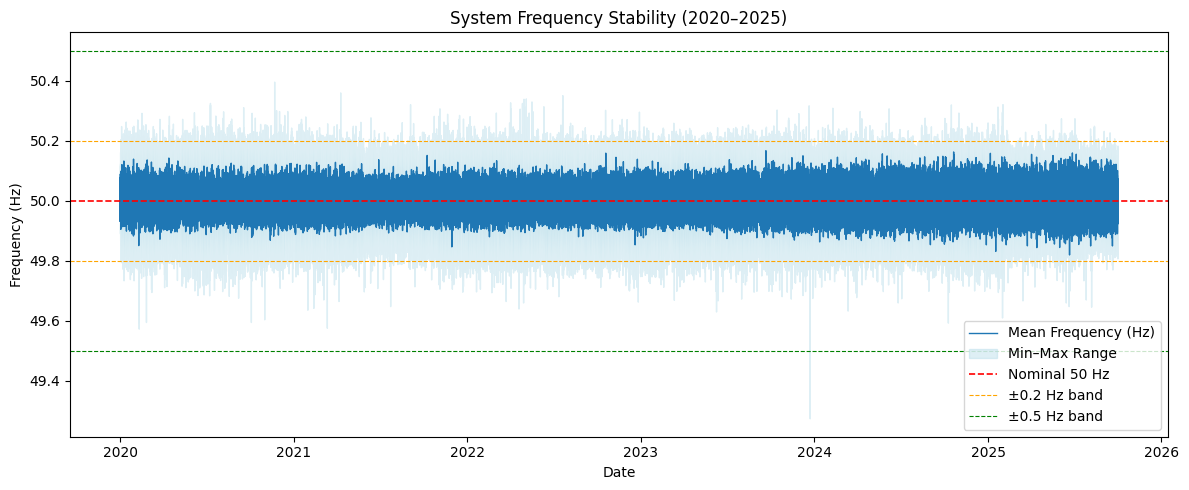

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df4["DATETIME"], df4["freq_mean"],
         label="Mean Frequency (Hz)", linewidth=1)
plt.fill_between(
    df4["DATETIME"], df4["freq_min"], df4["freq_max"],
    color="lightblue", alpha=0.4, label="Min–Max Range"
)
for hz, col, lw, lbl in [
    (50.0, "red",    1.2, "Nominal 50 Hz"),
    (49.8, "orange", 0.8, "±0.2 Hz band"),
    (50.2, "orange", 0.8, None),
    (49.5, "green",  0.8, "±0.5 Hz band"),
    (50.5, "green",  0.8, None),
]:
    plt.axhline(hz, color=col, linestyle="--", linewidth=lw,
                label=lbl if lbl else "")

plt.title("System Frequency Stability (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Frequency (Hz)")
plt.legend()
plt.tight_layout()
plt.show()


## 7. IQR Outlier Detection & Export
Detects IQR (1.5×) outliers for generation-mix, frequency, and weather features.  
Saves:
- `outliers_summary.csv` — per-feature counts and bounds  
- `outliers_all.csv`     — all flagged rows combined  
- `feature_outliers.zip` — one CSV per feature  


In [20]:
TIME_COL = "DATETIME"
OUT_DIR  = "feature_outliers"
COMBINED = "outliers_all.csv"
SUMMARY  = "outliers_summary.csv"
ZIP_NAME = "feature_outliers.zip"

df_in = df4.copy()

#  Feature groups
gen_mix = [c for c in ["GAS","COAL","NUCLEAR","WIND","WIND_EMB","HYDRO",
                       "IMPORTS","BIOMASS","OTHER","SOLAR","STORAGE",
                       "GENERATION","ND","TSD","CARBON_INTENSITY"]
           if c in df_in.columns]

freq_feats = [c for c in ["freq_mean","freq_min","freq_max","freq_std",
                           "out_of_49_5_50_5","out_of_49_8_50_2","n_points"]
              if c in df_in.columns]

weather_feats = [
    c for c in df_in.columns
    if any(k in c for k in
           ["Temperature","Wind Speed","Wind Direction",
            "Solar Irradiance","Cloud Cover","Precipitation"])
]

all_iqr_cols = list(dict.fromkeys(gen_mix + freq_feats + weather_feats))

# Safe filename helper
def safe_name(s: str) -> str:
    s = re.sub(r"[^A-Za-z0-9_.\-]+", "_", s).strip("_")
    return s[:120]

os.makedirs(OUT_DIR, exist_ok=True)
combined_rows, summary_rows = [], []

#  IQR per feature
for col in all_iqr_cols:
    s = df_in[col].astype(float)
    s_valid = s.dropna()
    if s_valid.empty:
        continue

    q1, q3  = s_valid.quantile(0.25), s_valid.quantile(0.75)
    iqr     = q3 - q1
    lo, hi  = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask    = (s < lo) | (s > hi)
    n_out   = int(mask.sum())

    if n_out > 0:
        feat_df = df_in.loc[mask, [TIME_COL, col]].copy()
        feat_df.insert(0, "Feature", col)
        feat_df["LowerBound"] = lo
        feat_df["UpperBound"] = hi
        feat_df["Method"]     = "IQR_1.5"
        feat_df.to_csv(os.path.join(OUT_DIR, f"outliers_{safe_name(col)}.csv"),
                       index=False)
        combined_rows.append(feat_df)

    summary_rows.append({
        "Feature": col, "Q1": q1, "Q3": q3, "IQR": iqr,
        "LowerBound": lo, "UpperBound": hi,
        "NumOutliers": n_out,
        "PctOutliers": round(100 * n_out / len(df_in), 4)
    })

#  Save outputs
if combined_rows:
    pd.concat(combined_rows, ignore_index=True) \
      .sort_values(["Feature", TIME_COL]) \
      .to_csv(COMBINED, index=False)
    print(f"✅ Combined outlier CSV: {COMBINED}")
else:
    print("ℹ️  No IQR outliers detected; combined file not created.")

summary_df = pd.DataFrame(summary_rows).sort_values("NumOutliers", ascending=False)
summary_df.to_csv(SUMMARY, index=False)
print(f"✅ Summary CSV: {SUMMARY}")
display(summary_df.head(15))

with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(OUT_DIR):
        zf.write(os.path.join(OUT_DIR, fname), arcname=fname)
print(f"✅ Zipped per-feature outliers: {ZIP_NAME}")


✅ Combined outlier CSV: outliers_all.csv
✅ Summary CSV: outliers_summary.csv


,Feature,Q1,Q3,IQR,LowerBound,UpperBound,NumOutliers,PctOutliers
23,Precipitation (mm)_aberdeen,0.0,0.0,0.0,0.00,0.00,21544,21.3730
41,Precipitation (mm)_ashford,0.0,0.0,0.0,0.00,0.00,19306,19.1528
29,Precipitation (mm)_humber,0.0,0.0,0.0,0.00,0.00,17508,17.3690
47,Precipitation (mm)_eastanglia,0.0,0.0,0.0,0.00,0.00,16086,15.9583
10,STORAGE,0.0,212.0,212.0,-318.00,530.00,13097,12.9931
35,Precipitation (mm)_camborne,0.0,0.1,0.1,-0.15,0.25,12784,12.6825
1,COAL,0.0,499.0,499.0,-748.50,1247.50,9046,8.9742
26,Solar Irradiance (W/m²)_aberdeen,0.0,182.0,182.0,-273.00,455.00,8654,8.5853
8,OTHER,149.0,354.0,205.0,-158.50,661.50,8534,8.4663
38,Solar Irradiance (W/m²)_camborne,0.0,225.0,225.0,-337.50,562.50,8130,8.0655


✅ Zipped per-feature outliers: feature_outliers.zip


## Feature Selection
Retain generation-mix, grid-frequency, demand, per-location weather,
calendar, holiday, and wind-extreme-flag columns.

In [21]:
selected_features = [
    "DATETIME",
    # Generation mix
    "GAS","COAL","NUCLEAR","WIND","WIND_EMB","HYDRO",
    "IMPORTS","BIOMASS","OTHER","SOLAR","STORAGE","GENERATION",
    # Grid frequency
    "freq_mean","freq_min","freq_max","freq_std",
    "out_of_49_5_50_5","out_of_49_8_50_2",
    # Weather — Aberdeen
    "Temperature (°C)_aberdeen","Precipitation (mm)_aberdeen",
    "Wind Speed (m/s)_aberdeen","Wind Direction (deg)_aberdeen",
    "Solar Irradiance (W/m²)_aberdeen","Cloud Cover (%)_aberdeen",
    # Weather — Humber
    "Temperature (°C)_humber","Precipitation (mm)_humber",
    "Wind Speed (m/s)_humber","Wind Direction (deg)_humber",
    "Solar Irradiance (W/m²)_humber","Cloud Cover (%)_humber",
    # Weather — Camborne
    "Temperature (°C)_camborne","Precipitation (mm)_camborne",
    "Wind Speed (m/s)_camborne","Wind Direction (deg)_camborne",
    "Solar Irradiance (W/m²)_camborne","Cloud Cover (%)_camborne",
    # Weather — Ashford
    "Temperature (°C)_ashford","Precipitation (mm)_ashford",
    "Wind Speed (m/s)_ashford","Wind Direction (deg)_ashford",
    "Solar Irradiance (W/m²)_ashford","Cloud Cover (%)_ashford",
    # Weather — East Anglia
    "Temperature (°C)_eastanglia","Precipitation (mm)_eastanglia",
    "Wind Speed (m/s)_eastanglia","Wind Direction (deg)_eastanglia",
    "Solar Irradiance (W/m²)_eastanglia","Cloud Cover (%)_eastanglia",
    # Calendar & flags
    "Day","Holiday","TSD",
    "WindExtremeFlag_aberdeen","WindExtremeFlag_humber",
    "WindExtremeFlag_camborne","WindExtremeFlag_ashford",
    "WindExtremeFlag_eastanglia",
]

# Keep only columns that actually exist in df4
selected_features = [c for c in selected_features if c in df4.columns]
df_selected = df4[selected_features].copy()

print(f"Selected dataframe shape: {df_selected.shape}")
print("Columns:", df_selected.columns.tolist())


Selected dataframe shape: (100800, 57)
Columns: ['DATETIME', 'GAS', 'COAL', 'NUCLEAR', 'WIND', 'WIND_EMB', 'HYDRO', 'IMPORTS', 'BIOMASS', 'OTHER', 'SOLAR', 'STORAGE', 'GENERATION', 'freq_mean', 'freq_min', 'freq_max', 'freq_std', 'out_of_49_5_50_5', 'out_of_49_8_50_2', 'Temperature (°C)_aberdeen', 'Precipitation (mm)_aberdeen', 'Wind Speed (m/s)_aberdeen', 'Wind Direction (deg)_aberdeen', 'Solar Irradiance (W/m²)_aberdeen', 'Cloud Cover (%)_aberdeen', 'Temperature (°C)_humber', 'Precipitation (mm)_humber', 'Wind Speed (m/s)_humber', 'Wind Direction (deg)_humber', 'Solar Irradiance (W/m²)_humber', 'Cloud Cover (%)_humber', 'Temperature (°C)_camborne', 'Precipitation (mm)_camborne', 'Wind Speed (m/s)_camborne', 'Wind Direction (deg)_camborne', 'Solar Irradiance (W/m²)_camborne', 'Cloud Cover (%)_camborne', 'Temperature (°C)_ashford', 'Precipitation (mm)_ashford', 'Wind Speed (m/s)_ashford', 'Wind Direction (deg)_ashford', 'Solar Irradiance (W/m²)_ashford', 'Cloud Cover (%)_ashford', 'Tem

## PCA — Weather Feature Reduction by Category
Applies PCA independently to each weather category (Temperature, Precipitation,
Wind, Solar, Cloud Cover) retaining 80 % explained variance per group.
Scree plots are produced for each category.


In [22]:
VAR_THRESHOLD = 0.80

# Column groupings
def cols_containing(df, substrings):
    return [c for c in df.columns if any(s in c for s in substrings)]

categories = {
    "TEMP":   cols_containing(df_selected, ["Temperature (°C)_"]),
    "PRECIP": cols_containing(df_selected, ["Precipitation (mm)_"]),
    "WIND":   cols_containing(df_selected, ["Wind Speed (m/s)_", "Wind Direction (deg)_"]),
    "SOLAR":  cols_containing(df_selected, ["Solar Irradiance (W/m²)_"]),
    "CLOUD":  cols_containing(df_selected, ["Cloud Cover (%)_"]),
}

#  PCA helper
def pca_for_group(df, cols, prefix, var_threshold=0.80):
    if not cols:
        return pd.DataFrame(index=df.index), None, np.array([])
    X_raw    = df[cols].fillna(0.0)
    X_scaled = StandardScaler().fit_transform(X_raw)
    pca      = PCA(n_components=var_threshold, svd_solver="full")
    X_pca    = pca.fit_transform(X_scaled)
    comp_names = [f"{prefix}_PCA_{i+1}" for i in range(X_pca.shape[1])]
    return (
        pd.DataFrame(X_pca, columns=comp_names, index=df.index),
        pca,
        pca.explained_variance_ratio_
    )

# Run PCA per category
pca_frames = []
evr_dict   = {}

for cat, cols in categories.items():
    df_pca, model, evr = pca_for_group(df_selected, cols, cat, VAR_THRESHOLD)
    pca_frames.append(df_pca)
    evr_dict[cat] = evr
    msg = (
        f"{cat:>6} | {len(cols):2d} raw cols → {df_pca.shape[1]:2d} PCs | "
        f"Cumulative variance: {evr.cumsum()[-1]:.3f}"
        if evr.size else f"{cat:>6} |  0 →  0 PCs | (no columns found)"
    )
    print(msg)


  TEMP |  5 raw cols →  1 PCs | Cumulative variance: 0.925
PRECIP |  5 raw cols →  4 PCs | Cumulative variance: 0.867
  WIND | 10 raw cols →  5 PCs | Cumulative variance: 0.835
 SOLAR |  5 raw cols →  1 PCs | Cumulative variance: 0.909
 CLOUD |  5 raw cols →  3 PCs | Cumulative variance: 0.809


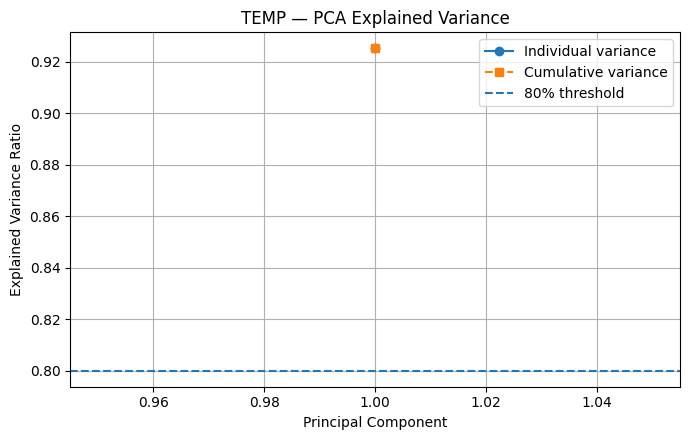

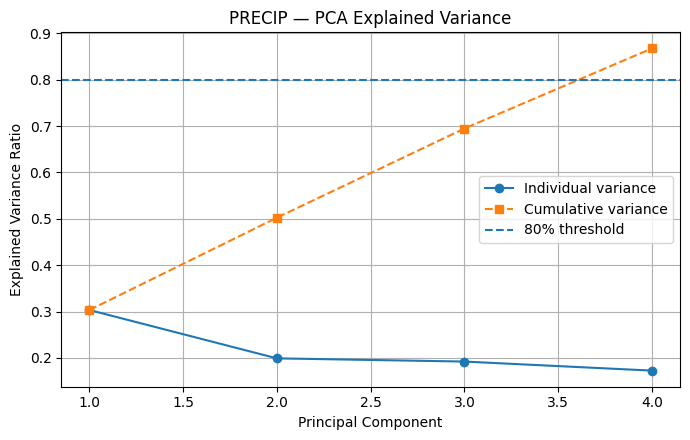

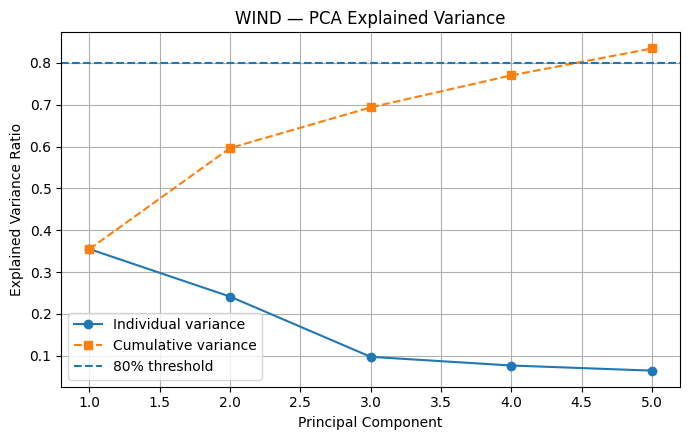

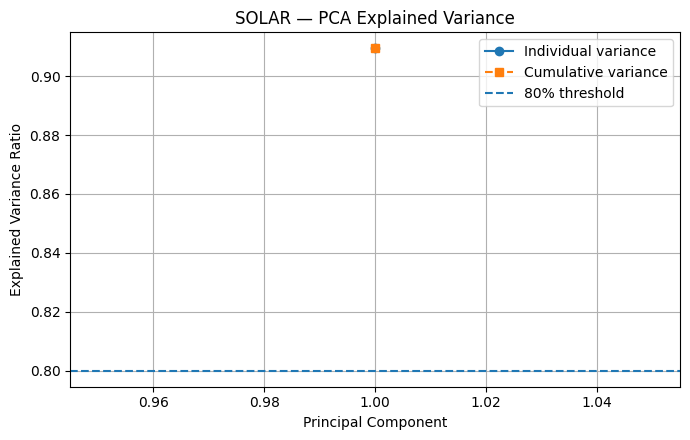

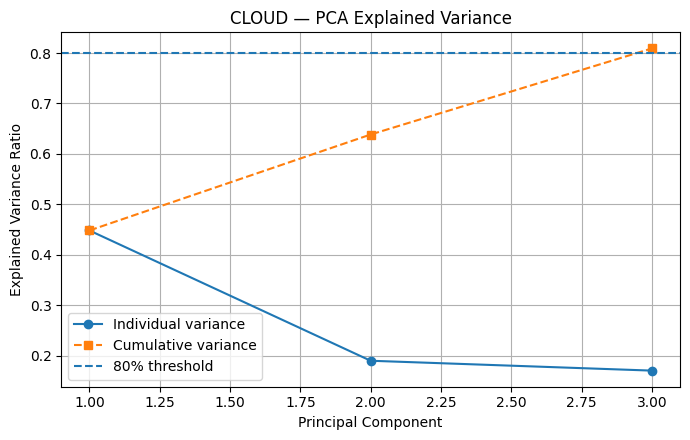

In [23]:
# Scree plots per weather category
for cat, evr in evr_dict.items():
    if evr.size == 0:
        continue
    cum = evr.cumsum()
    xs  = range(1, len(evr) + 1)

    plt.figure(figsize=(7, 4.5))
    plt.plot(xs, evr,  "o-",  label="Individual variance")
    plt.plot(xs, cum,  "s--", label="Cumulative variance")
    plt.axhline(VAR_THRESHOLD, linestyle="--",
                label=f"{int(VAR_THRESHOLD*100)}% threshold")
    plt.title(f"{cat} — PCA Explained Variance")
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [24]:
# Build final dataset: drop raw weather cols, concatenate PCA cols
all_weather_cols = sum(categories.values(), [])
non_weather = df_selected.drop(columns=all_weather_cols, errors="ignore")
df_final    = pd.concat([non_weather] + pca_frames, axis=1)

if "DATETIME" in df_final.columns:
    df_final = df_final.sort_values("DATETIME").reset_index(drop=True)

print(f"✅ PCA completed.  Final shape: {df_final.shape}")
print("PCA columns added:", [c for c in df_final.columns if "_PCA_" in c])


✅ PCA completed.  Final shape: (100800, 41)
PCA columns added: ['TEMP_PCA_1', 'PRECIP_PCA_1', 'PRECIP_PCA_2', 'PRECIP_PCA_3', 'PRECIP_PCA_4', 'WIND_PCA_1', 'WIND_PCA_2', 'WIND_PCA_3', 'WIND_PCA_4', 'WIND_PCA_5', 'SOLAR_PCA_1', 'CLOUD_PCA_1', 'CLOUD_PCA_2', 'CLOUD_PCA_3']


## Post-PCA Correlation Analysis
Full heatmap + focused view on pairs with |r| > 0.80.  
Identifies the WIND / WIND_EMB multicollinearity that motivates creating `WIND_TOTAL`.


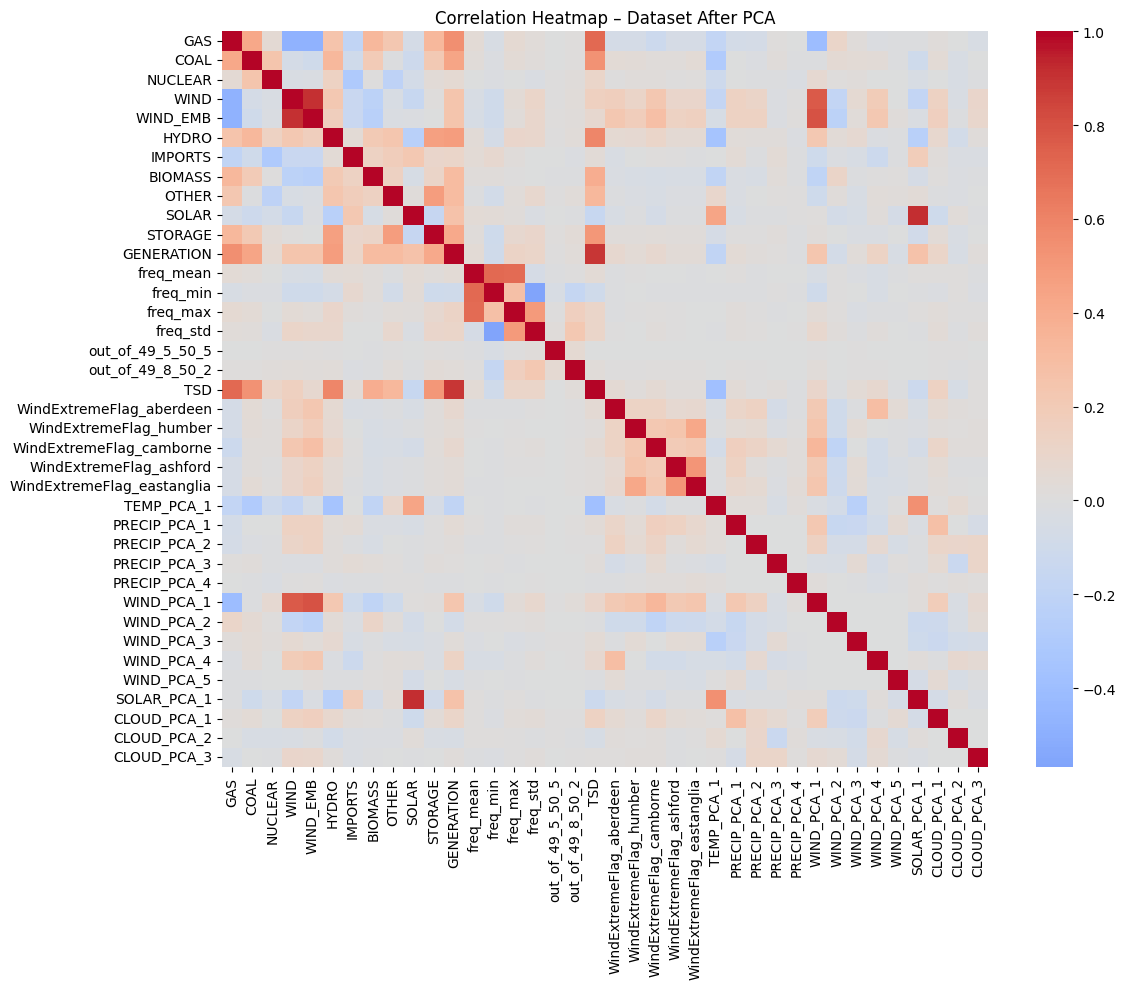

In [25]:
# Full correlation heatmap
corr_full = df_final.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_full, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap – Dataset After PCA")
plt.tight_layout()
plt.show()


In [26]:
# Pairs with |r| > 0.80
corr_abs  = df_final.select_dtypes(include="number").corr().abs()
upper_tri = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

high_corr_pairs2 = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Correlation"})
    .query("Correlation > 0.8")
    .sort_values("Correlation", ascending=False)
)
print(f"Total pairs with correlation > 0.80: {len(high_corr_pairs2)}")
display(high_corr_pairs2)


Total pairs with correlation > 0.80: 4


,Feature_1,Feature_2,Correlation
321,SOLAR,SOLAR_PCA_1,0.915972
108,WIND,WIND_EMB,0.904018
358,GENERATION,TSD,0.891282
166,WIND_EMB,WIND_PCA_1,0.802152


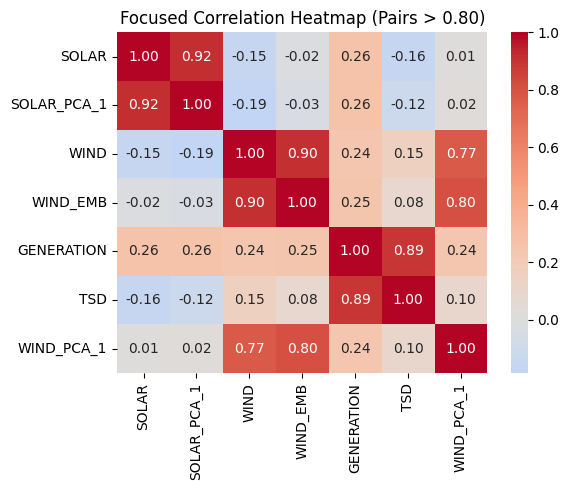

In [27]:
# Focused heatmap on the most correlated features
focus_candidates = ["SOLAR","SOLAR_PCA_1","WIND","WIND_EMB",
                    "GENERATION","TSD","WIND_PCA_1"]
focus_cols = [c for c in focus_candidates if c in df_final.columns]

if len(focus_cols) > 1:
    plt.figure(figsize=(6, 5))
    sns.heatmap(df_final[focus_cols].corr(), annot=True,
                cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Focused Correlation Heatmap (Pairs > 0.80)")
    plt.tight_layout()
    plt.show()


## Resolve WIND / WIND_EMB Multicollinearity
Merge onshore (`WIND`) and embedded (`WIND_EMB`) wind into a single `WIND_TOTAL`
to eliminate the high VIF / high correlation between those columns.


In [28]:
df_final["WIND_TOTAL"] = df_selected["WIND"] + df_selected["WIND_EMB"]
df_final2 = df_final.drop(columns=["WIND", "WIND_EMB"], errors="ignore")

# Verify no remaining high-correlation pairs involving these features
corr_abs2  = df_final2.select_dtypes(include="number").corr().abs()
upper_tri2 = corr_abs2.where(
    np.triu(np.ones(corr_abs2.shape), k=1).astype(bool)
)
high_corr2 = (
    upper_tri2.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Correlation"})
    .query("Correlation > 0.8")
    .sort_values("Correlation", ascending=False)
)
print(f"Pairs with |r| > 0.80 after WIND_TOTAL merge: {len(high_corr2)}")
display(high_corr2)
print(f"\ndf_final2 shape: {df_final2.shape}")


Pairs with |r| > 0.80 after WIND_TOTAL merge: 2


,Feature_1,Feature_2,Correlation
255,SOLAR,SOLAR_PCA_1,0.915972
294,GENERATION,TSD,0.891282



df_final2 shape: (100800, 40)


## Grid Resilience Index (GRI) Computation
A custom **5-parameter weighted index** (0–100):

| Component | Formula | Weight |
|-----------|---------|--------|
| **M** Supply–Demand Margin | clip(max(0, Gen−Dem−2%Dem) / ref, 0, 1) | 0.40 |
| **D** Fuel-Mix Diversity | clip(1 − HHI, 0, 1) — inverse Herfindahl | 0.20 |
| **I** Import Dependence | clip(1 − (share−5%)/(40%−5%), 0, 1) | 0.10 |
| **S** Storage Contribution | clip(storage/demand / 5%, 0, 1) | 0.10 |
| **F** Frequency Stability | clip(1 − (|50−f̄|−0.10)/0.40, 0, 1) | 0.20 |

**GRI = 100 × (0.40M + 0.20D + 0.10I + 0.10S + 0.20F)**


In [30]:
df_gri = df_final2.copy()

generation = df_gri["GENERATION"].astype(float)
demand     = df_gri["TSD"].astype(float)
ref_capacity = float(generation.max()) if generation.max() > 0 else 1.0

#  M: Supply–Demand Margin
margin_mw = generation - demand
M = np.clip(
    np.maximum(0.0, margin_mw - 0.02 * demand) / ref_capacity,
    0.0, 1.0
)

#  D: Fuel-Mix Diversity (inverse HHI)
fuel_cols_gri = [
    c for c in ["GAS","COAL","NUCLEAR","HYDRO","IMPORTS","BIOMASS",
                "OTHER","SOLAR","STORAGE","WIND_TOTAL"]
    if c in df_gri.columns
]
fuel_mat   = df_gri[fuel_cols_gri].astype(float)
fuel_total = fuel_mat.sum(axis=1)
shares     = fuel_mat.div(fuel_total.replace(0, np.nan), axis=0).fillna(0.0)
HHI        = (shares ** 2).sum(axis=1)
D          = np.clip(1.0 - HHI, 0.0, 1.0)

#  I: Import Dependence
imports       = df_gri["IMPORTS"].astype(float) if "IMPORTS" in df_gri.columns else 0.0
imports_share = np.where(generation > 0, imports / generation, 0.0)
I             = np.clip(1.0 - (imports_share - 0.05) / (0.40 - 0.05), 0.0, 1.0)

# S: Storage Contribution
storage = df_gri["STORAGE"].astype(float) if "STORAGE" in df_gri.columns else 0.0
S = np.clip(
    np.where(demand > 0, np.maximum(0.0, storage) / demand / 0.05, 0.0),
    0.0, 1.0
)

# F: Frequency Stability
fmean = df_gri["freq_mean"].astype(float)
delta = np.abs(50.0 - fmean)
F     = np.clip(1.0 - (delta - 0.10) / (0.50 - 0.10), 0.0, 1.0)

# Weighted GRI
wM, wD, wI, wS, wF = 0.40, 0.20, 0.10, 0.10, 0.20
GRI = 100.0 * (wM*M + wD*D + wI*I + wS*S + wF*F)

df_gri["M"]   = M
df_gri["D"]   = D
df_gri["I"]   = I
df_gri["S"]   = S
df_gri["F"]   = F
df_gri["GRI"] = GRI

print("✅ GRI computed. Preview:")
display(df_gri[["DATETIME","M","D","I","S","F","GRI"]].head())
print("\nGRI summary:")
print(df_gri["GRI"].describe())

df_final2_with_GRI = df_gri.copy()
print(f"\nShape with GRI: {df_final2_with_GRI.shape}")


✅ GRI computed. Preview:


,DATETIME,M,D,I,S,F,GRI
0,2020-01-01 00:00:00+00:00,0.003314,0.788681,0.835980,0.030199,1.0,44.567982
1,2020-01-01 00:30:00+00:00,0.001937,0.785718,0.846022,0.044791,1.0,44.699964
2,2020-01-01 01:00:00+00:00,0.000023,0.786432,0.845277,0.000000,1.0,44.182343
3,2020-01-01 01:30:00+00:00,0.000000,0.787878,0.840175,0.000000,1.0,44.159308
4,2020-01-01 02:00:00+00:00,0.000000,0.789203,0.838108,0.000000,1.0,44.165141



GRI summary:
count    100078.000000
mean         45.940514
std           3.351345
min          35.573152
25%          43.582365
50%          45.427664
75%          48.251443
max          59.300860
Name: GRI, dtype: float64

Shape with GRI: (100800, 46)


In [ ]:
## GRI Component Statistical Summary

In [34]:
gri_stat_cols = [c for c in ["GRI","M","D","I","S","F"]
                 if c in df_final2_with_GRI.columns]

stats_df = pd.DataFrame({
    "Minimum":           df_final2_with_GRI[gri_stat_cols].min(),
    "Q1 (25%)":          df_final2_with_GRI[gri_stat_cols].quantile(0.25),
    "Median (50%)":      df_final2_with_GRI[gri_stat_cols].median(),
    "Q3 (75%)":          df_final2_with_GRI[gri_stat_cols].quantile(0.75),
    "Maximum":           df_final2_with_GRI[gri_stat_cols].max(),
    "Range (Max − Min)": df_final2_with_GRI[gri_stat_cols].max()
                         - df_final2_with_GRI[gri_stat_cols].min(),
    "IQR (Q3 − Q1)":    df_final2_with_GRI[gri_stat_cols].quantile(0.75)
                         - df_final2_with_GRI[gri_stat_cols].quantile(0.25),
    "Mean":              df_final2_with_GRI[gri_stat_cols].mean(),
    "Std Dev":           df_final2_with_GRI[gri_stat_cols].std(),
})

print("===== GRI Component Statistical Summary =====")
display(stats_df)
stats_df.to_excel("GRI_component_statistics.xlsx")
print("Saved to GRI_component_statistics.xlsx")


===== GRI Component Statistical Summary =====


,Minimum,Q1 (25%),Median (50%),Q3 (75%),Maximum,Range (Max − Min),IQR (Q3 − Q1),Mean,Std Dev
GRI,35.573152,43.582365,45.427664,48.251443,59.300860,23.727708,4.669078,45.940514,3.351345
M,0.000000,0.015842,0.039597,0.081511,0.380438,0.380438,0.065669,0.056758,0.054627
D,0.443134,0.688354,0.734233,0.770127,0.850107,0.406973,0.081774,0.724502,0.060811
I,0.041247,0.693834,0.833448,0.961764,1.000000,0.958753,0.267930,0.804124,0.173638
S,0.000000,0.000000,0.000000,0.136465,1.000000,1.000000,0.136465,0.113345,0.204741
F,0.798500,1.000000,1.000000,1.000000,1.000000,0.201500,0.000000,0.999477,0.005360


Saved to GRI_component_statistics.xlsx


In [33]:
## GRI Time-Series Visualisation

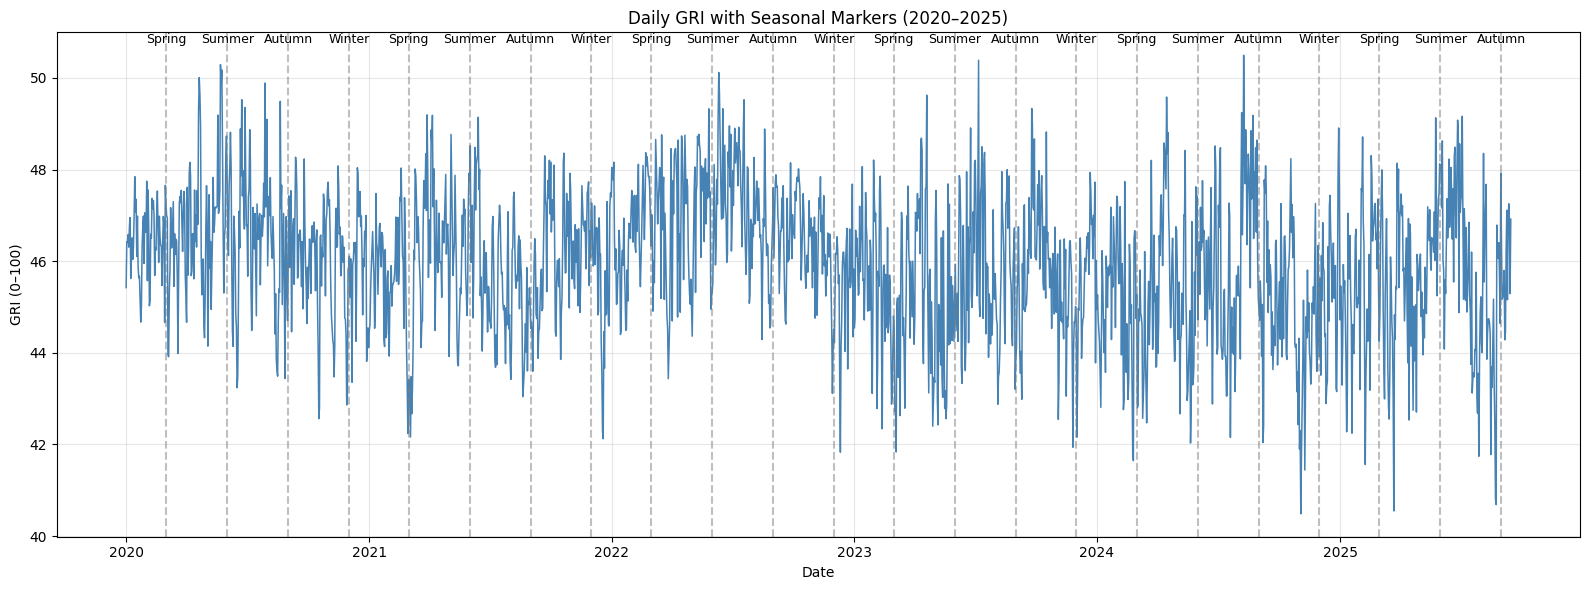

In [37]:
#  GRI with seasonal markers

df_viz = df_final2_with_GRI.copy()
df_viz["DATETIME"] = pd.to_datetime(df_viz["DATETIME"], utc=True)
gri_daily = df_viz.resample("D", on="DATETIME")["GRI"].mean()

def make_season_dates(start_year=2020, end_year=2025):
    dates, labels = [], []
    for y in range(start_year, end_year + 1):
        dates  += [pd.Timestamp(f"{y}-03-01", tz="UTC"),
                   pd.Timestamp(f"{y}-06-01", tz="UTC"),
                   pd.Timestamp(f"{y}-09-01", tz="UTC"),
                   pd.Timestamp(f"{y}-12-01", tz="UTC")]
        labels += ["Spring", "Summer", "Autumn", "Winter"]
    return dates, labels

season_dates, season_labels = make_season_dates()


plt.figure(figsize=(16, 6))
plt.plot(gri_daily.index, gri_daily.values,
         color="steelblue", linewidth=1.1, label="Daily GRI")

for dt, lbl in zip(season_dates, season_labels):
    if gri_daily.index.min() <= dt <= gri_daily.index.max():
        plt.axvline(dt, linestyle="--", color="gray", alpha=0.5)
        plt.text(dt, gri_daily.max() + 0.2, lbl,
                 rotation=0, fontsize=9, ha="center", va="bottom")

plt.title("Daily GRI with Seasonal Markers (2020–2025)")
plt.xlabel("Date")
plt.ylabel("GRI (0–100)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## GRI Component Visualisations

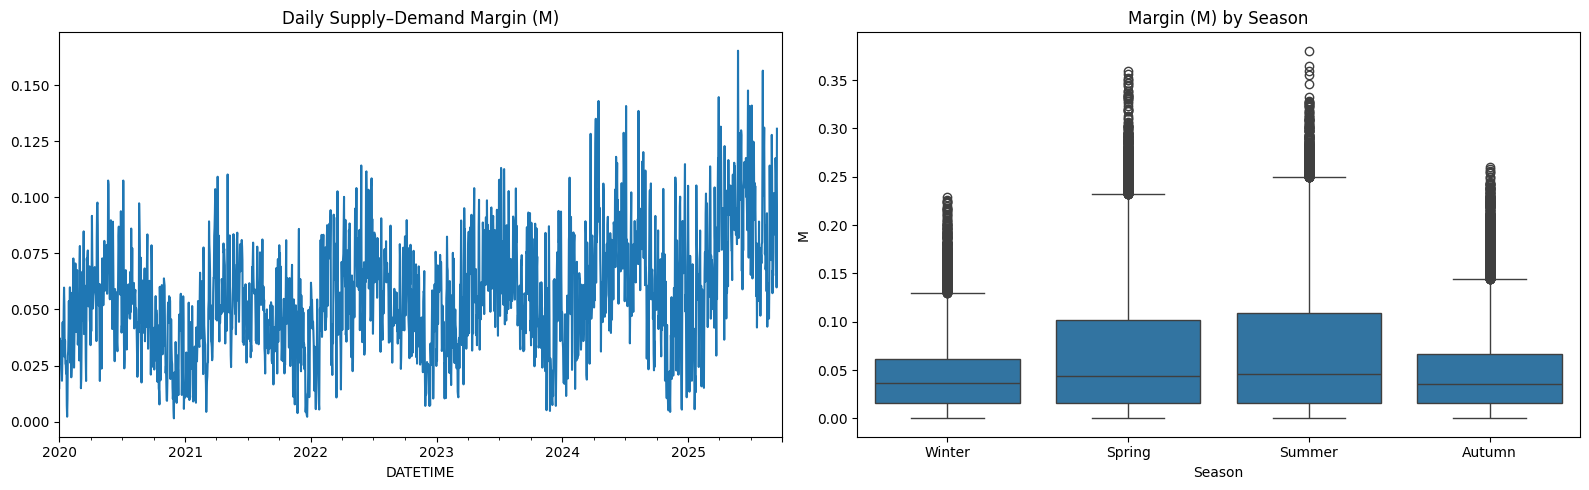

In [38]:
df_comp = df_final2_with_GRI.copy()
df_comp["DATETIME"] = pd.to_datetime(df_comp["DATETIME"], utc=True)
df_comp = df_comp.set_index("DATETIME")

def month_to_season(m):
    return {12:"Winter",1:"Winter",2:"Winter",
            3:"Spring",4:"Spring",5:"Spring",
            6:"Summer",7:"Summer",8:"Summer"}.get(m, "Autumn")

df_comp["Season"] = df_comp.index.month.map(month_to_season)

# Supply–Demand Margin (M)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
df_comp["M"].resample("D").mean().plot(ax=ax[0], title="Daily Supply–Demand Margin (M)")
sns.boxplot(x="Season", y="M",
            order=["Winter","Spring","Summer","Autumn"],
            data=df_comp, ax=ax[1])
ax[1].set_title("Margin (M) by Season")
plt.tight_layout()
plt.show()


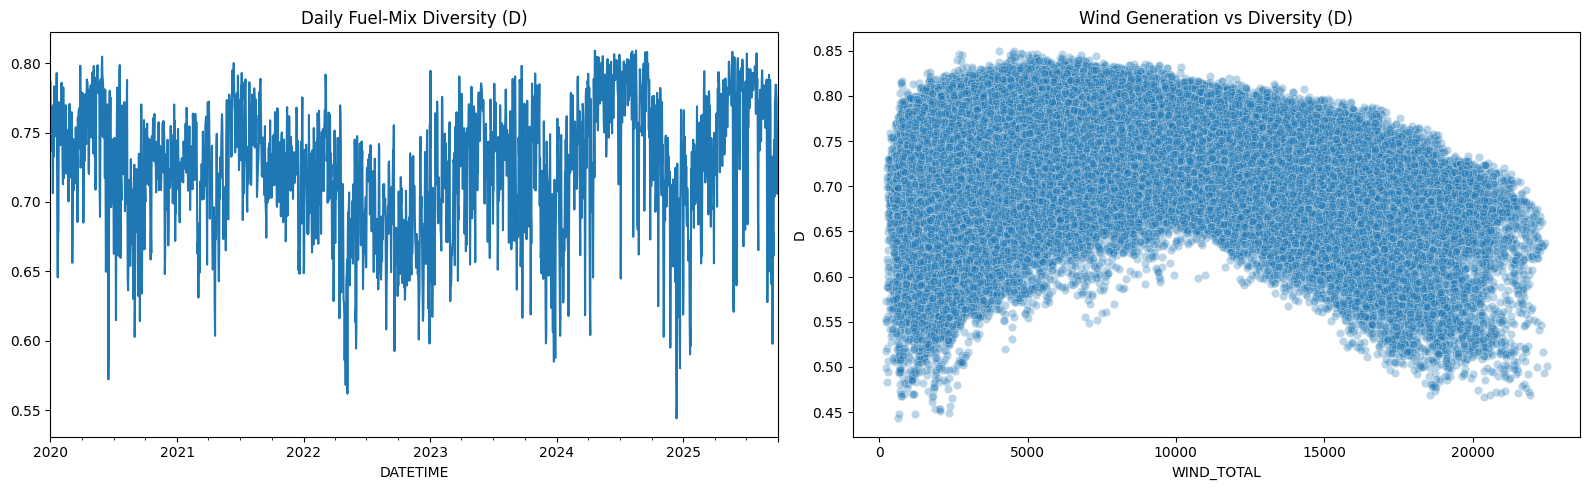

In [43]:
#  Fuel-Mix Diversity (D)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
df_comp["D"].resample("D").mean().plot(ax=ax[0], title="Daily Fuel-Mix Diversity (D)")
sns.scatterplot(x=df_comp["WIND_TOTAL"], y=df_comp["D"], alpha=0.3, ax=ax[1])
ax[1].set_title("Wind Generation vs Diversity (D)")
plt.tight_layout()
plt.show()


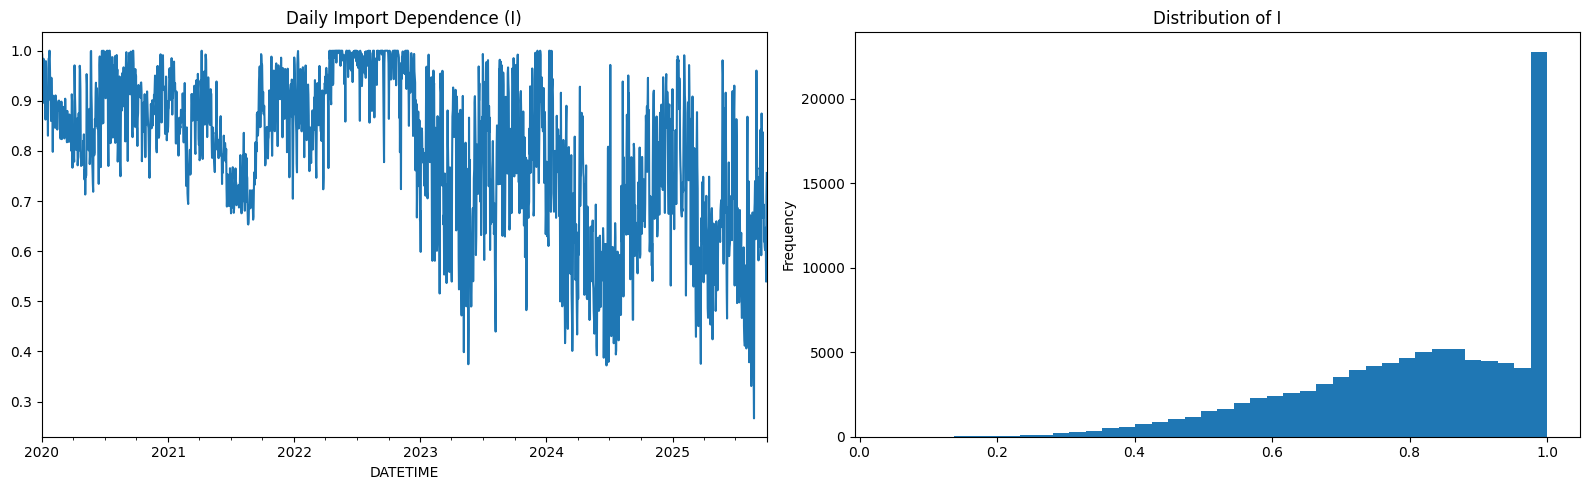

In [44]:
# Import Dependence (I)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
df_comp["I"].resample("D").mean().plot(ax=ax[0], title="Daily Import Dependence (I)")
df_comp["I"].plot(kind="hist", bins=40, ax=ax[1], title="Distribution of I")
plt.tight_layout()
plt.show()


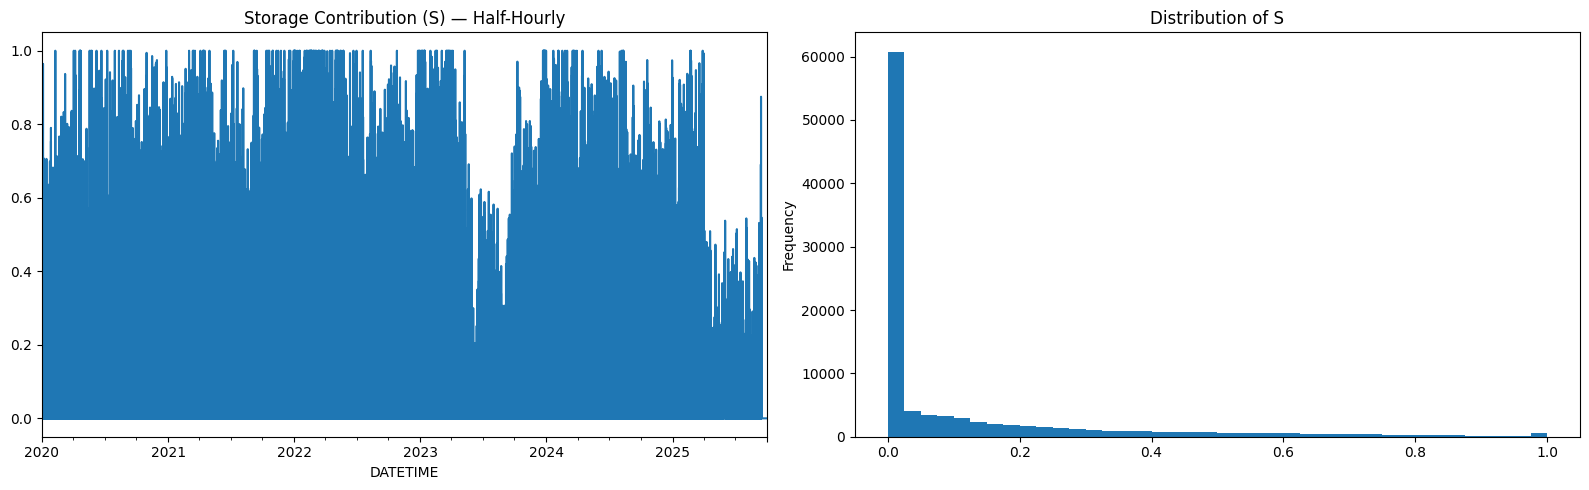

In [45]:
# Storage Contribution (S)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
df_comp["S"].plot(ax=ax[0], title="Storage Contribution (S) — Half-Hourly")
df_comp["S"].plot(kind="hist", bins=40, ax=ax[1], title="Distribution of S")
plt.tight_layout()
plt.show()


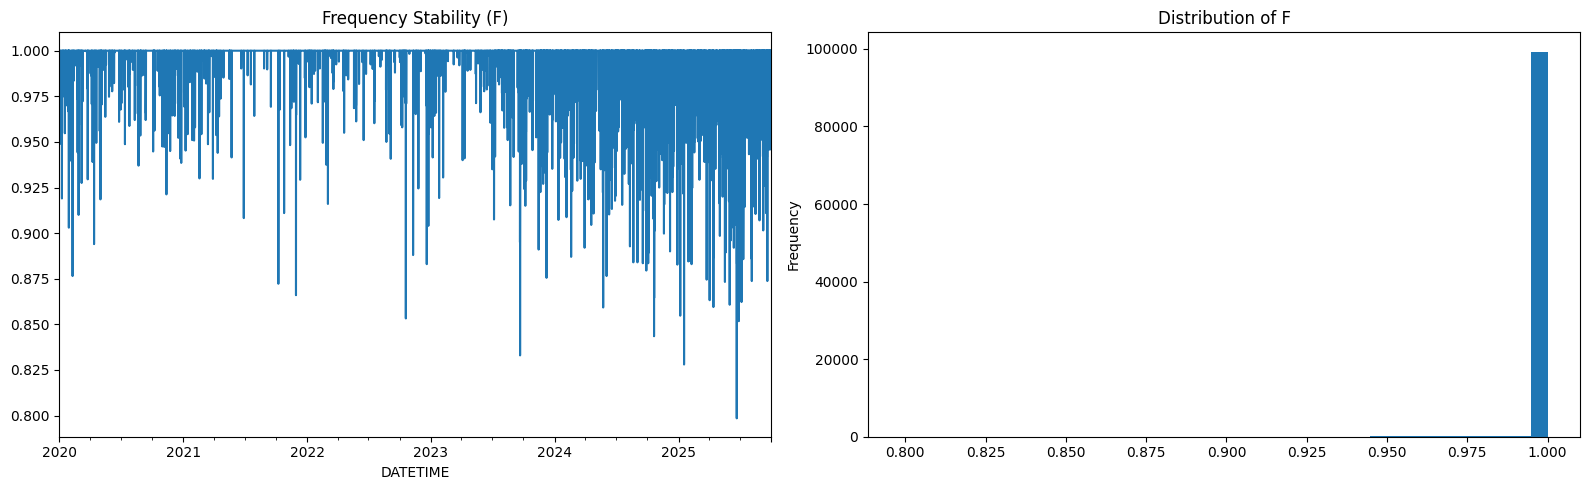

Frequency disturbance events (F < 0.6): 0


,GAS,COAL,NUCLEAR,HYDRO,IMPORTS,BIOMASS,OTHER,SOLAR,STORAGE,GENERATION,freq_mean,freq_min,freq_max,freq_std,out_of_49_5_50_5,out_of_49_8_50_2,Day,Holiday,TSD,WindExtremeFlag_aberdeen,WindExtremeFlag_humber,WindExtremeFlag_camborne,WindExtremeFlag_ashford,WindExtremeFlag_eastanglia,TEMP_PCA_1,PRECIP_PCA_1,PRECIP_PCA_2,PRECIP_PCA_3,PRECIP_PCA_4,WIND_PCA_1,WIND_PCA_2,WIND_PCA_3,WIND_PCA_4,WIND_PCA_5,SOLAR_PCA_1,CLOUD_PCA_1,CLOUD_PCA_2,CLOUD_PCA_3,WIND_TOTAL,M,D,I,S,F,GRI,Season
DATETIME,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


In [46]:
#  Frequency Stability (F)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
df_comp["F"].plot(ax=ax[0], title="Frequency Stability (F)")
df_comp["F"].plot(kind="hist", bins=40, ax=ax[1], title="Distribution of F")
plt.tight_layout()
plt.show()

disturbance_events = df_comp[df_comp["F"] < 0.6]
print(f"Frequency disturbance events (F < 0.6): {len(disturbance_events)}")
display(disturbance_events.head())


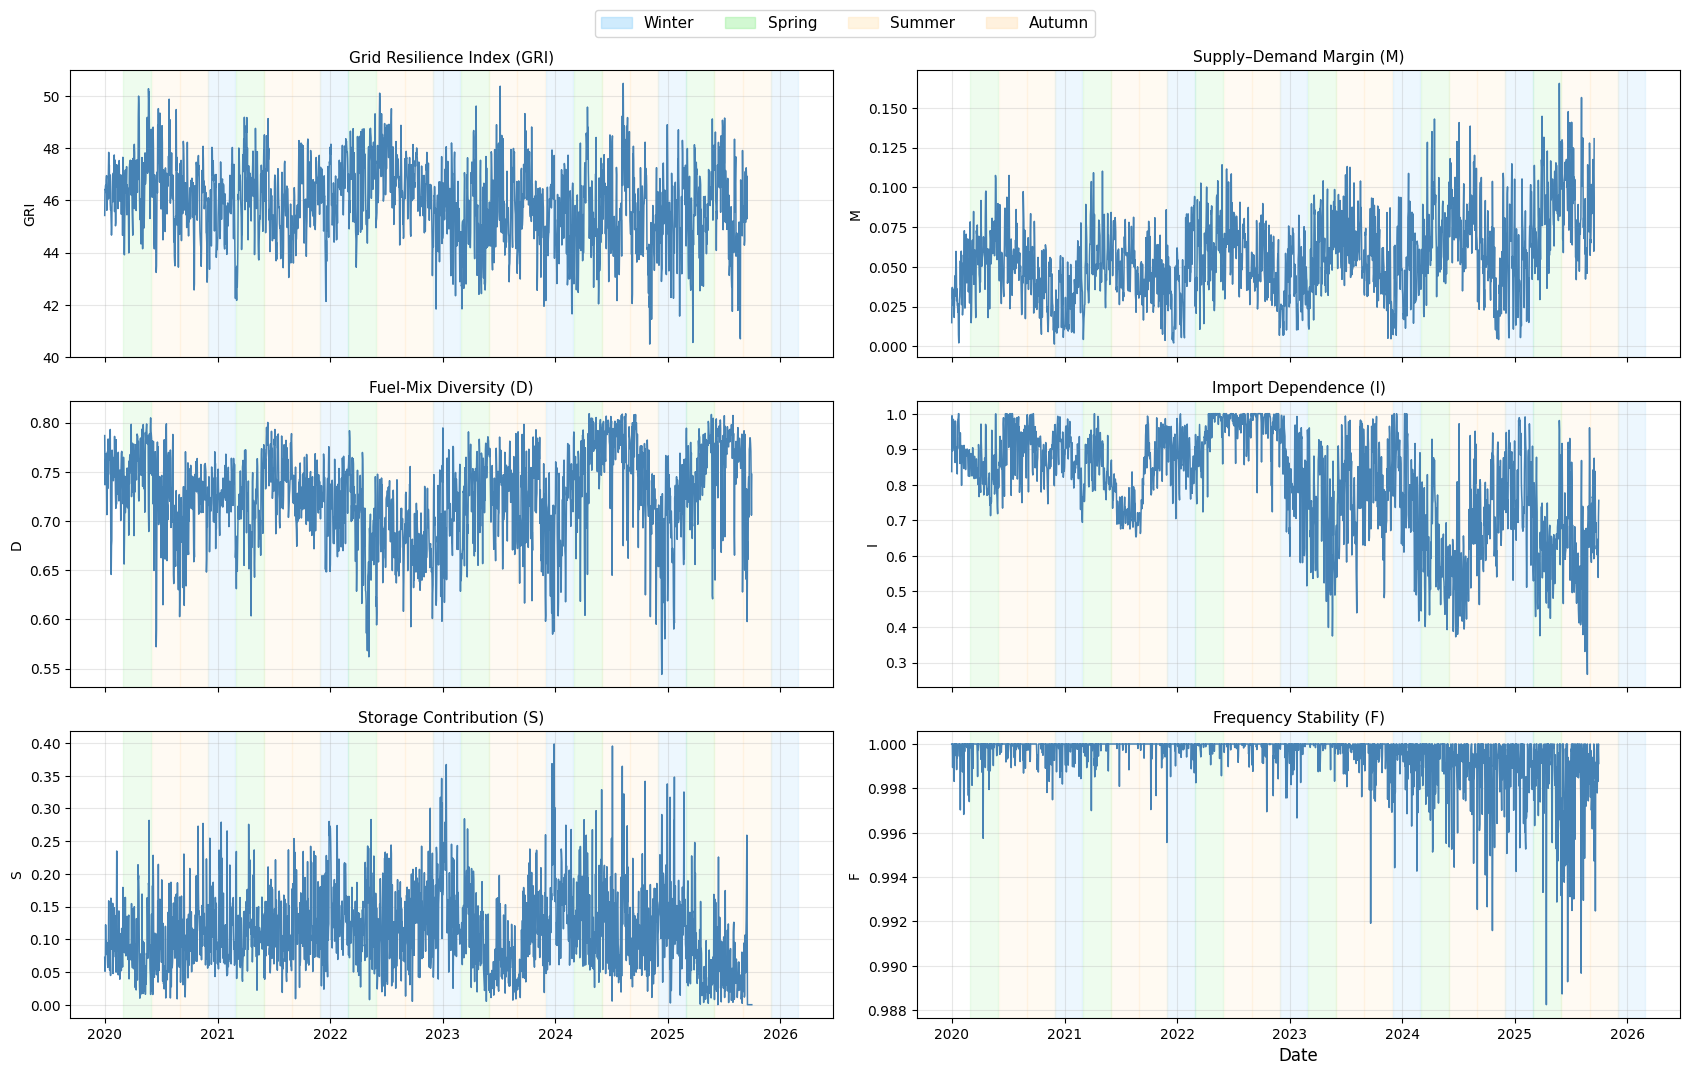

In [47]:
#  Combined panel: all 6 components with seasonal shading
season_colors = {
    "Winter": "lightskyblue", "Spring": "lightgreen",
    "Summer": "moccasin",     "Autumn": "navajowhite"
}

def get_season_intervals(idx):
    years = sorted(set(idx.year))
    intervals = []
    for y in years:
        intervals += [
            (pd.Timestamp(f"{y}-12-01", tz="UTC"),
             pd.Timestamp(f"{y+1}-02-28", tz="UTC"), "Winter"),
            (pd.Timestamp(f"{y}-03-01",  tz="UTC"),
             pd.Timestamp(f"{y}-05-31",  tz="UTC"), "Spring"),
            (pd.Timestamp(f"{y}-06-01",  tz="UTC"),
             pd.Timestamp(f"{y}-08-31",  tz="UTC"), "Summer"),
            (pd.Timestamp(f"{y}-09-01",  tz="UTC"),
             pd.Timestamp(f"{y}-11-30",  tz="UTC"), "Autumn"),
        ]
    return intervals

df_daily_comp = df_comp[["GRI","M","D","I","S","F"]].resample("D").mean()
season_intervals = get_season_intervals(df_daily_comp.index)

titles_map = {
    "GRI": "Grid Resilience Index (GRI)",
    "M":   "Supply–Demand Margin (M)",
    "D":   "Fuel-Mix Diversity (D)",
    "I":   "Import Dependence (I)",
    "S":   "Storage Contribution (S)",
    "F":   "Frequency Stability (F)",
}

fig, axes = plt.subplots(3, 2, figsize=(17, 11), sharex=True)
axes = axes.flatten()

for ax, comp in zip(axes, ["GRI","M","D","I","S","F"]):
    for start, end, season in season_intervals:
        ax.axvspan(start, end, color=season_colors[season], alpha=0.15)
    ax.plot(df_daily_comp.index, df_daily_comp[comp],
            linewidth=1.1, color="steelblue")
    ax.set_title(titles_map[comp], fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel(comp)

legend_patches = [
    mpatches.Patch(color=season_colors[s], alpha=0.4, label=s)
    for s in ["Winter","Spring","Summer","Autumn"]
]
fig.legend(handles=legend_patches, loc="upper center",
           ncol=4, fontsize=11, bbox_to_anchor=(0.5, 0.98))
plt.xlabel("Date", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


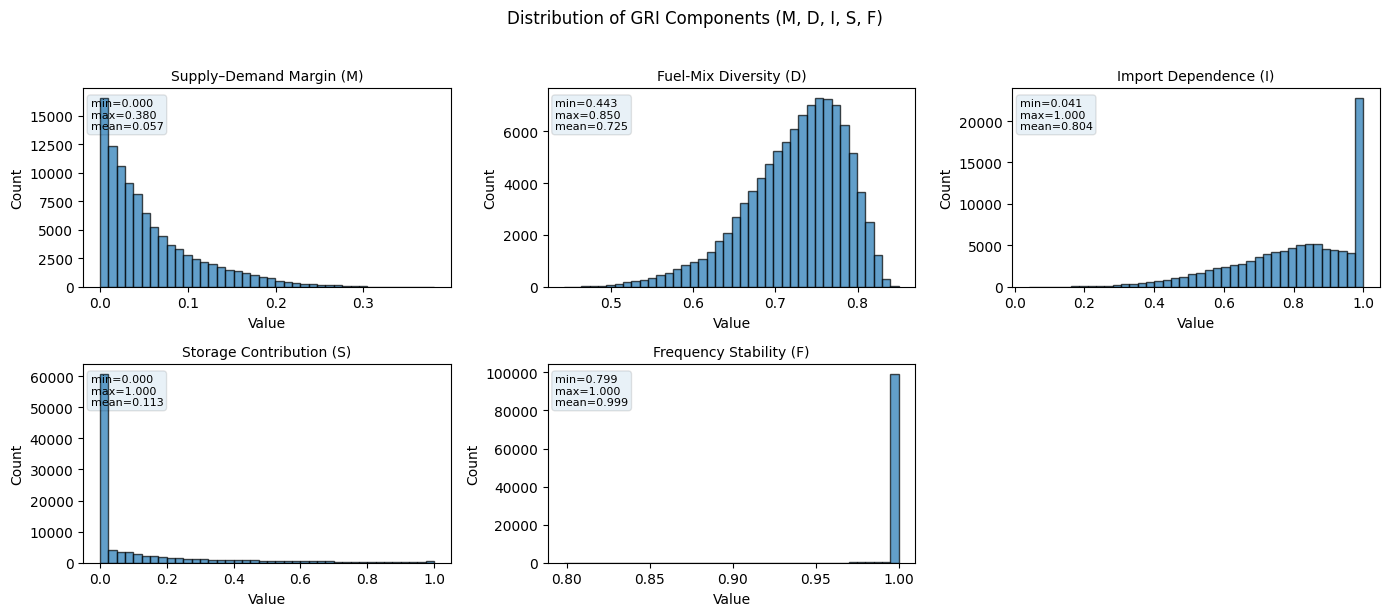

In [48]:

#  Histograms of M, D, I, S, F

components = ["M","D","I","S","F"]
titles_h   = {
    "M": "Supply–Demand Margin (M)",
    "D": "Fuel-Mix Diversity (D)",
    "I": "Import Dependence (I)",
    "S": "Storage Contribution (S)",
    "F": "Frequency Stability (F)",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()

for i, comp in enumerate(components):
    ax     = axes[i]
    series = df_final2_with_GRI[comp].dropna()
    ax.hist(series, bins=40, edgecolor="black", alpha=0.7)
    ax.set_title(titles_h[comp], fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.text(0.02, 0.95,
            f"min={series.min():.3f}\nmax={series.max():.3f}\nmean={series.mean():.3f}",
            transform=ax.transAxes, va="top", fontsize=8,
            bbox=dict(boxstyle="round", alpha=0.1))

axes[-1].axis("off")
plt.suptitle("Distribution of GRI Components (M, D, I, S, F)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## Seasonal & Correlation Analysis of GRI Components
- Global Q1 / Q3 thresholds
- Seasonal below-Q1 and above-Q3 counts
- Pearson correlation matrix
- Co-occurrence analysis (low GRI ∧ low component; high GRI ∧ high component)


In [49]:
df_sea = df_final2_with_GRI.copy()
df_sea["DATETIME"] = pd.to_datetime(df_sea["DATETIME"], utc=True)
df_sea["season"]   = df_sea["DATETIME"].dt.month.map(month_to_season)

sea_cols     = ["GRI","M","D","I","S","F"]
season_order = ["Winter","Spring","Summer","Autumn"]

q1_global = df_sea[sea_cols].quantile(0.25)
q3_global = df_sea[sea_cols].quantile(0.75)

print("===== Global Q1 (25th percentile) =====")
print(q1_global)
print("\n===== Global Q3 (75th percentile) =====")
print(q3_global)


===== Global Q1 (25th percentile) =====
GRI    43.582365
M       0.015842
D       0.688354
I       0.693834
S       0.000000
F       1.000000
Name: 0.25, dtype: float64

===== Global Q3 (75th percentile) =====
GRI    48.251443
M       0.081511
D       0.770127
I       0.961764
S       0.136465
F       1.000000
Name: 0.75, dtype: float64


In [50]:
#  Seasonal below-Q1 counts
low_mask = df_sea[sea_cols].lt(q1_global, axis=1)
low_mask["season"] = df_sea["season"]

seasonal_low = (low_mask.groupby("season")[sea_cols]
                .sum().reindex(season_order).fillna(0))

print("===== 30-min records BELOW Q1 by season =====")
display(seasonal_low)


===== 30-min records BELOW Q1 by season =====


,GRI,M,D,I,S,F
season,,,,,,
Winter,5070,6054,7419,3638,0,392
Spring,7762,6747,5819,8515,0,438
Summer,7025,6496,5045,8901,0,514
Autumn,5163,5723,6917,4146,0,420


In [51]:
#  Seasonal above-Q3 counts
high_mask = df_sea[sea_cols].gt(q3_global, axis=1)
high_mask["season"] = df_sea["season"]

seasonal_high = (high_mask.groupby("season")[sea_cols]
                 .sum().reindex(season_order).fillna(0))

print("===== 30-min records ABOVE Q3 by season =====")
display(seasonal_high)


===== 30-min records ABOVE Q3 by season =====


,GRI,M,D,I,S,F
season,,,,,,
Winter,4496,3234,3425,6222,7018,0
Spring,7655,8379,8022,4319,6259,0
Summer,7887,9159,9403,7197,5974,0
Autumn,4982,4248,4350,7462,5949,0


===== Pearson Correlation Matrix =====


,GRI,M,D,I,S,F
GRI,1.000000,0.629774,0.277993,0.320937,0.525871,0.015351
M,0.629774,1.000000,0.276067,-0.029931,-0.171546,-0.052353
D,0.277993,0.276067,1.000000,-0.541987,0.026522,-0.022560
I,0.320937,-0.029931,-0.541987,1.000000,0.031762,0.037577
S,0.525871,-0.171546,0.026522,0.031762,1.000000,0.011167
F,0.015351,-0.052353,-0.022560,0.037577,0.011167,1.000000


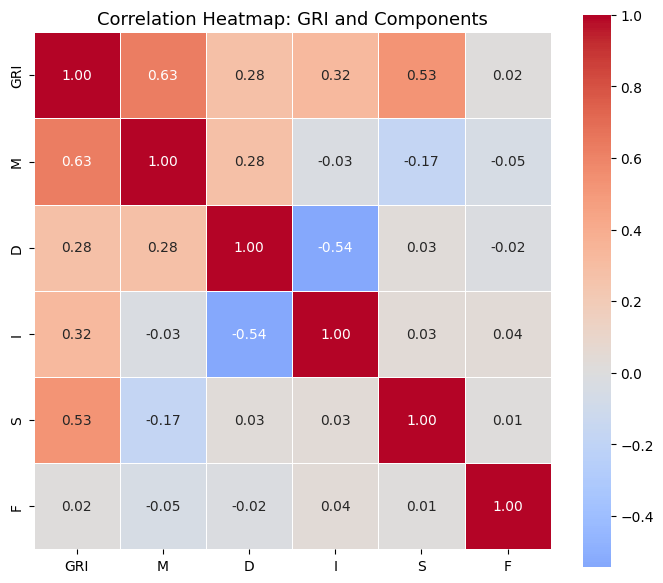

In [52]:
# Pearson correlation heatmap
corr_gri = df_sea[sea_cols].corr(method="pearson")
print("===== Pearson Correlation Matrix =====")
display(corr_gri)

plt.figure(figsize=(7, 6))
sns.heatmap(corr_gri, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap: GRI and Components", fontsize=13)
plt.tight_layout()
plt.show()


In [54]:
# Co-occurrence analysis
components_co = ["M","D","I","S","F"]

mask_low_GRI  = df_sea["GRI"] < q1_global["GRI"]
mask_high_GRI = df_sea["GRI"] > q3_global["GRI"]

co_low_dict  = {c: int(((df_sea["GRI"] < q1_global["GRI"]) &
                         (df_sea[c]   < q1_global[c])).sum()) for c in components_co}
co_high_dict = {c: int(((df_sea["GRI"] > q3_global["GRI"]) &
                         (df_sea[c]   > q3_global[c])).sum()) for c in components_co}

co_low_df = (pd.DataFrame.from_dict(co_low_dict, orient="index",
                                     columns=["Co-occurrence Count"])
             .assign(**{"% of Low-GRI Periods":
                 lambda x: x["Co-occurrence Count"] / mask_low_GRI.sum() * 100})
             .sort_values("% of Low-GRI Periods", ascending=False))

co_high_df = (pd.DataFrame.from_dict(co_high_dict, orient="index",
                                      columns=["Co-occurrence Count"])
              .assign(**{"% of High-GRI Periods":
                  lambda x: x["Co-occurrence Count"] / mask_high_GRI.sum() * 100})
              .sort_values("% of High-GRI Periods", ascending=False))

print(f"\n===== Co-occurrence: GRI < Q1 AND component < Q1 =====")
print(f"Total low-GRI periods: {mask_low_GRI.sum()}")
display(co_low_df)

print(f"\n===== Co-occurrence: GRI > Q3 AND component > Q3 =====")
print(f"Total high-GRI periods: {mask_high_GRI.sum()}")
display(co_high_df)



===== Co-occurrence: GRI < Q1 AND component < Q1 =====
Total low-GRI periods: 25020


,Co-occurrence Count,% of Low-GRI Periods
M,14603,58.365308
I,12368,49.432454
D,8646,34.556355
F,509,2.034373
S,0,0.000000



===== Co-occurrence: GRI > Q3 AND component > Q3 =====
Total high-GRI periods: 25020


,Co-occurrence Count,% of High-GRI Periods
M,15152,60.559552
S,12777,51.067146
D,9450,37.769784
I,7048,28.169464
F,0,0.000000


In [55]:
# Export seasonal / correlation analysis to Excel
out_file = "GRI_seasonal_corr_cooccurrence_analysis.xlsx"
with pd.ExcelWriter(out_file) as writer:
    q1_global.to_frame("Q1").to_excel(writer, sheet_name="Global_Q1_thresholds")
    q3_global.to_frame("Q3").to_excel(writer, sheet_name="Global_Q3_thresholds")
    seasonal_low.to_excel(writer,  sheet_name="Seasonal_Below_Q1_counts")
    seasonal_high.to_excel(writer, sheet_name="Seasonal_Above_Q3_counts")
    corr_gri.to_excel(writer,      sheet_name="Correlation_matrix")
    co_low_df.to_excel(writer,     sheet_name="Cooccurrence_Low_GRI")
    co_high_df.to_excel(writer,    sheet_name="Cooccurrence_High_GRI")

print(f"✅ Analysis exported to {out_file}")


✅ Analysis exported to GRI_seasonal_corr_cooccurrence_analysis.xlsx


## Temporal Feature Engineering
Adds:
- **Lags**: generation, frequency, demand (lags 1–3); weather PCA (lags 1–2)
- **Rolling statistics**: mean and std over 3-slot and 6-slot windows
- **Calendar features**: year, month, dayofyear, dayofweek, hour, is_weekend,
  cyclic hour and month encodings
- **Holiday encoding**: binary 0/1


In [56]:
# Config
GEN_LAGS    = [1, 2, 3]
FREQ_LAGS   = [1, 2, 3]
DEMAND_LAGS = [1, 2, 3]
WEATH_LAGS  = [1, 2]
ROLL_WINDOWS = [3, 6]
ADD_CALENDAR = True
DROP_NA_AFTER = True

def _safe_cols(df, cols):
    return [c for c in cols if c in df.columns]

def add_lags(df, lag_map):
    out = df.copy()
    for col, lags in lag_map.items():
        if col not in out.columns:
            continue
        for l in lags:
            out[f"{col}_lag{l}"] = out[col].shift(l)
    return out

def add_rolling(df, cols, windows):
    out  = df.copy()
    cols = _safe_cols(out, cols)
    for col in cols:
        for w in windows:
            out[f"{col}_roll{w}_mean"] = out[col].rolling(w, min_periods=w).mean()
            out[f"{col}_roll{w}_std"]  = out[col].rolling(w, min_periods=w).std()
    return out

def add_calendar(df, datetime_col="DATETIME"):
    out = df.copy()
    if datetime_col not in out.columns:
        return out
    dt = pd.to_datetime(out[datetime_col], utc=True, errors="coerce")
    out[datetime_col] = dt
    out["year"]       = dt.dt.year
    out["month"]      = dt.dt.month
    out["dayofyear"]  = dt.dt.dayofyear
    out["dayofweek"]  = dt.dt.dayofweek
    out["hour"]       = dt.dt.hour
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    out["hour_sin"]   = np.sin(2 * np.pi * out["hour"]  / 24.0)
    out["hour_cos"]   = np.cos(2 * np.pi * out["hour"]  / 24.0)
    out["month_sin"]  = np.sin(2 * np.pi * out["month"] / 12.0)
    out["month_cos"]  = np.cos(2 * np.pi * out["month"] / 12.0)
    return out

#  Feature groups
GENERATION_FEATURES = _safe_cols(df_final2_with_GRI, [
    "GAS","COAL","NUCLEAR","HYDRO","IMPORTS","BIOMASS","OTHER",
    "SOLAR","STORAGE","WIND_TOTAL","GENERATION"
])
FREQUENCY_FEATURES = _safe_cols(df_final2_with_GRI, [
    "freq_mean","freq_min","freq_max","freq_std",
    "out_of_49_5_50_5","out_of_49_8_50_2"
])
DEMAND_FEATURES  = _safe_cols(df_final2_with_GRI, ["TSD"])
WEATHER_FEATURES = [
    c for c in df_final2_with_GRI.columns
    if any(p in c for p in
           ["TEMP_PCA_","PRECIP_PCA_","WIND_PCA_","SOLAR_PCA_","CLOUD_PCA_"])
]

LAG_SPEC = {}
for col in GENERATION_FEATURES: LAG_SPEC[col] = GEN_LAGS
for col in FREQUENCY_FEATURES:  LAG_SPEC[col] = FREQ_LAGS
for col in DEMAND_FEATURES:     LAG_SPEC[col] = DEMAND_LAGS
for col in WEATHER_FEATURES:    LAG_SPEC[col] = WEATH_LAGS

ROLL_COLS = GENERATION_FEATURES + FREQUENCY_FEATURES + DEMAND_FEATURES + WEATHER_FEATURES

# Run pipeline
df_feat2 = df_final2_with_GRI.copy()
df_feat2["DATETIME"] = pd.to_datetime(df_feat2["DATETIME"], utc=True, errors="coerce")
df_feat2 = df_feat2.sort_values("DATETIME").reset_index(drop=True)

df_feat2 = add_lags(df_feat2, LAG_SPEC)
df_feat2 = add_rolling(df_feat2, ROLL_COLS, ROLL_WINDOWS)

if ADD_CALENDAR:
    df_feat2 = add_calendar(df_feat2, "DATETIME")

if "Holiday" in df_feat2.columns:
    df_feat2["Holiday"] = (
        df_feat2["Holiday"].astype(str).str.strip().str.lower()
        .map({"yes": 1, "no": 0}).fillna(0).astype("int8")
    )

if "Day" in df_feat2.columns:
    df_feat2 = df_feat2.drop(columns=["Day"])

# Drop GRI sub-components from feature set (used only to build GRI, not predictors)
df_feat2 = df_feat2.drop(columns=["M","D","I","S","F"], errors="ignore")

if DROP_NA_AFTER:
    before   = len(df_feat2)
    df_feat2 = df_feat2.dropna().reset_index(drop=True)
    print(f"Dropped {before - len(df_feat2)} rows due to lag/rolling NaNs.")

added_cols = [c for c in df_feat2.columns if "_lag" in c or "_roll" in c]
print(f"✅ Feature engineering complete.")
print(f"   Added {len(added_cols)} derived columns (lags/rolling).")
print(f"   Final shape: {df_feat2.shape}")


Dropped 727 rows due to lag/rolling NaNs.
✅ Feature engineering complete.
   Added 210 derived columns (lags/rolling).
   Final shape: (100073, 260)


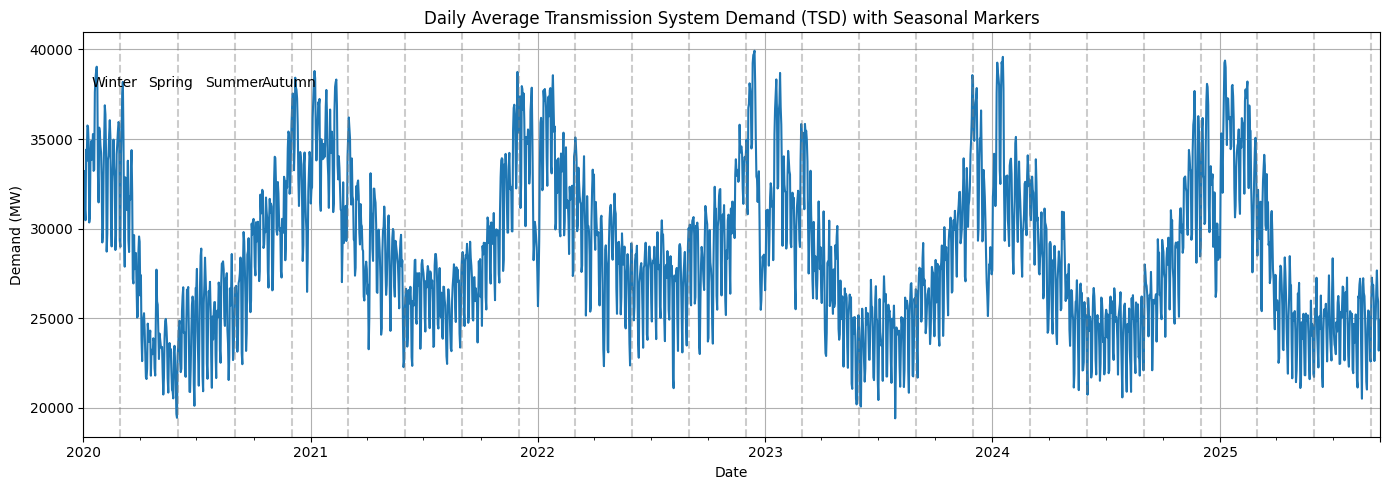

In [57]:
# Seasonal TSD trend
daily_TSD = df_feat2.set_index("DATETIME")["TSD"].resample("D").mean()

plt.figure(figsize=(14, 5))
daily_TSD.plot()

season_markers = [
    f"{y}-{m:02d}-01"
    for y in range(2020, 2026)
    for m in [3, 6, 9, 12]
]
for sc in season_markers:
    plt.axvline(pd.to_datetime(sc), linestyle="--", color="gray", alpha=0.4)

for ts, lbl in [
    ("2020-01-15", "Winter"),("2020-04-15", "Spring"),
    ("2020-07-15", "Summer"),("2020-10-15", "Autumn")
]:
    plt.text(pd.to_datetime(ts), daily_TSD.max() * 0.95, lbl, fontsize=10)

plt.title("Daily Average Transmission System Demand (TSD) with Seasonal Markers")
plt.ylabel("Demand (MW)")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()


## XGBoost — 6-Hour-Ahead GRI Forecasting

**Horizon:** H = 12 half-hour periods = 6 hours ahead  
**Time split:**
- Train : 2020-01-01 → 2023-12-31
- Test  : 2024-01-01 → 2025-08-31


In [58]:
H = 12   # 6-hour forecast horizon

df_xgb = df_feat2.copy()
df_xgb["DATETIME"] = pd.to_datetime(df_xgb["DATETIME"], utc=True, errors="coerce")

# Future target
df_xgb["GRI_t_plus_H"] = df_xgb["GRI"].shift(-H)
df_xgb = df_xgb.dropna(subset=["GRI_t_plus_H"]).reset_index(drop=True)

#  Time split
train_start = pd.Timestamp("2020-01-01", tz="UTC")
train_end   = pd.Timestamp("2023-12-31", tz="UTC")
test_end    = pd.Timestamp("2025-08-31", tz="UTC")

train_mask = (df_xgb["DATETIME"] >= train_start) & (df_xgb["DATETIME"] <= train_end)
test_mask  = (df_xgb["DATETIME"] >  train_end)   & (df_xgb["DATETIME"] <= test_end)

print(f"Train rows : {train_mask.sum()}")
print(f"Test rows  : {test_mask.sum()}")

feature_cols = [
    c for c in df_xgb.columns
    if c not in ["DATETIME", "GRI", "GRI_t_plus_H"]
]

X = df_xgb[feature_cols]
y = df_xgb["GRI_t_plus_H"]

X_train_6h, y_train_6h = X[train_mask], y[train_mask]
X_test_6h,  y_test_6h  = X[test_mask],  y[test_mask]
print(f"Feature count: {X_train_6h.shape[1]}")


Train rows : 70076
Test rows  : 29232
Feature count: 258


## XGBoost — Hyperparameter Search (RandomizedSearchCV)
Uses `TimeSeriesSplit` (n=5 folds) to respect temporal ordering during cross-validation.  
Searches over a broad grid of depth, learning rate, subsampling, and regularisation.  
Best parameters are then used to retrain the final model.


In [59]:
# Parameter grid
param_dist = {
    "n_estimators":      [200, 300, 500, 700],
    "max_depth":         [4, 5, 6, 7, 8],
    "learning_rate":     [0.01, 0.03, 0.05, 0.08, 0.10],
    "subsample":         [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":  [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight":  [1, 3, 5, 7],
    "reg_alpha":         [0, 0.01, 0.1, 0.5, 1.0],
    "reg_lambda":        [0.5, 1.0, 2.0, 5.0],
    "gamma":             [0, 0.1, 0.5, 1.0],
}

# TimeSeriesSplit respects temporal ordering
tscv = TimeSeriesSplit(n_splits=5)

RANDOM_STATE = 42
base_xgb = XGBRegressor(
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="rmse",
)

rs_xgb = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)



print("Running RandomizedSearchCV (n_iter=50, cv=5 time-series folds)…")
rs_xgb.fit(X_train_6h, y_train_6h)

print("\n✅ Best CV score (RMSE):", -rs_xgb.best_score_)
print("Best parameters found:")
for k, v in rs_xgb.best_params_.items():
    print(f"  {k:25s}: {v}")


Running RandomizedSearchCV (n_iter=50, cv=5 time-series folds)…
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Best CV score (RMSE): 1.9706486785081536
Best parameters found:
  subsample                : 0.9
  reg_lambda               : 1.0
  reg_alpha                : 1.0
  n_estimators             : 300
  min_child_weight         : 3
  max_depth                : 6
  learning_rate            : 0.03
  gamma                    : 0
  colsample_bytree         : 1.0


In [60]:
# Retrain best model on full training set
xgb_best = XGBRegressor(
    **rs_xgb.best_params_,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_best.fit(X_train_6h, y_train_6h)

pred_best  = xgb_best.predict(X_test_6h)
r2_best    = r2_score(y_test_6h, pred_best)
mae_best   = mean_absolute_error(y_test_6h, pred_best)
rmse_best  = np.sqrt(mean_squared_error(y_test_6h, pred_best))

print(f"\n=== XGBoost Best Model (6h-ahead GRI) ===")
print(f"R²   : {r2_best:.4f}")
print(f"MAE  : {mae_best:.4f}")
print(f"RMSE : {rmse_best:.4f}")



=== XGBoost Best Model (6h-ahead GRI) ===
R²   : 0.6620
MAE  : 1.6657
RMSE : 2.1417


## XGBoost — Baseline Model & Comparison
A fixed-hyperparameter baseline (n_estimators=300, lr=0.05, depth=6) is trained
alongside the tuned best model for direct comparison.


In [61]:
#  Baseline model
xgb_base = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_base.fit(X_train_6h, y_train_6h)

pred_base = xgb_base.predict(X_test_6h)
r2_base   = r2_score(y_test_6h, pred_base)
mae_base  = mean_absolute_error(y_test_6h, pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test_6h, pred_base))

print("=== XGBoost Baseline (fixed params) ===")
print(f"R²   : {r2_base:.4f}")
print(f"MAE  : {mae_base:.4f}")
print(f"RMSE : {rmse_base:.4f}")

print("\n=== XGBoost Best (tuned params) ===")
print(f"R²   : {r2_best:.4f}")
print(f"MAE  : {mae_best:.4f}")
print(f"RMSE : {rmse_best:.4f}")

compare_xgb = pd.DataFrame({
    "Model":    ["XGBoost Baseline", "XGBoost Best (Tuned)"],
    "R²":       [r2_base,  r2_best],
    "MAE":      [mae_base, mae_best],
    "RMSE":     [rmse_base, rmse_best],
})
display(compare_xgb)


=== XGBoost Baseline (fixed params) ===
R²   : 0.6607
MAE  : 1.6682
RMSE : 2.1456

=== XGBoost Best (tuned params) ===
R²   : 0.6620
MAE  : 1.6657
RMSE : 2.1417


,Model,R²,MAE,RMSE
0,XGBoost Baseline,0.660731,1.668173,2.145589
1,XGBoost Best (Tuned),0.661958,1.665703,2.141704


In [62]:
# For downstream analysis we use the best model predictions
pred = pred_best
xgb_h = xgb_best   # alias kept for compatibility with SHAP code below


## XGBoost — Diagnostic Plots

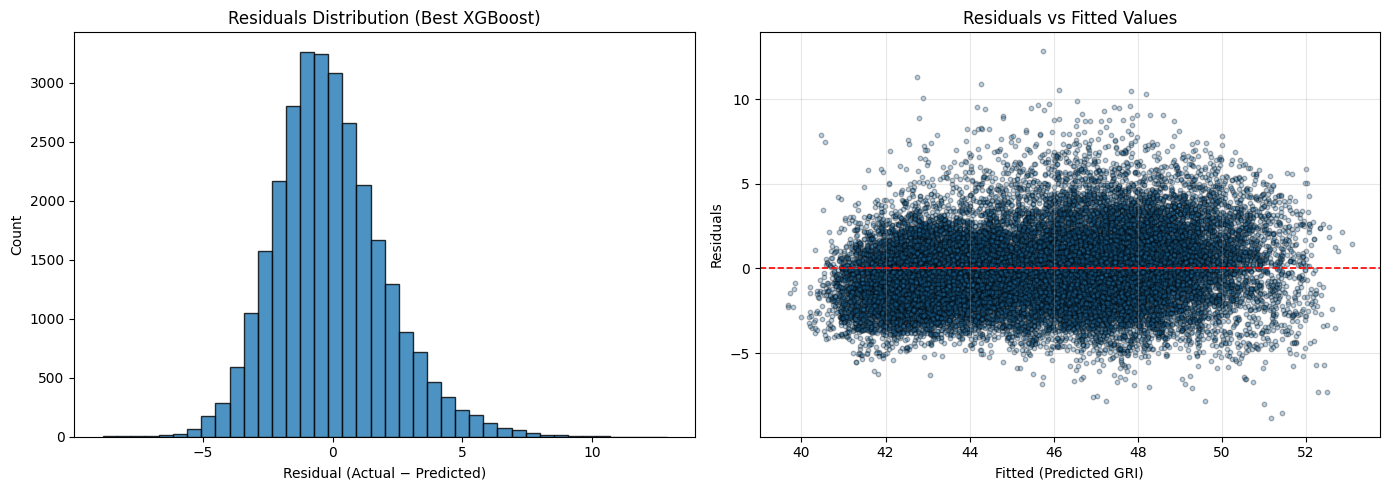

In [63]:
residuals = y_test_6h - pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual histogram
axes[0].hist(residuals, bins=40, edgecolor="black", alpha=0.8)
axes[0].set_title("Residuals Distribution (Best XGBoost)")
axes[0].set_xlabel("Residual (Actual − Predicted)")
axes[0].set_ylabel("Count")

# Residuals vs Fitted
axes[1].scatter(pred, residuals, alpha=0.3, edgecolor="k", s=10)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.2)
axes[1].set_title("Residuals vs Fitted Values")
axes[1].set_xlabel("Fitted (Predicted GRI)")
axes[1].set_ylabel("Residuals")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


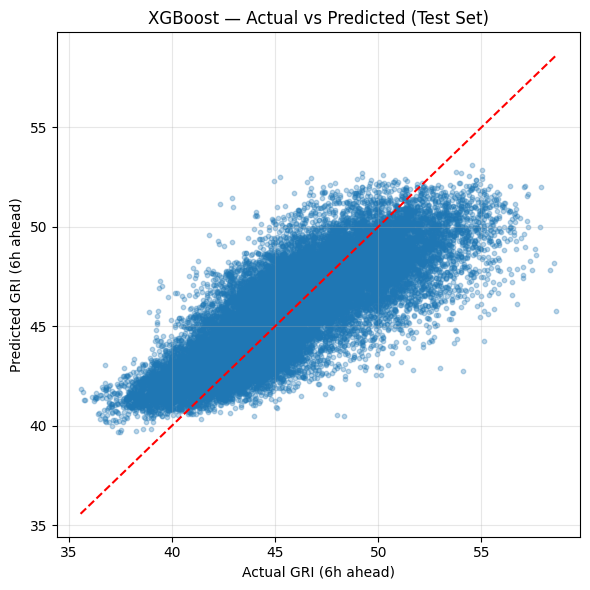

In [64]:
#  Actual vs Predicted scatter
plt.figure(figsize=(6, 6))
plt.scatter(y_test_6h, pred, alpha=0.3, s=10)
mn, mx = y_test_6h.min(), y_test_6h.max()
plt.plot([mn, mx], [mn, mx], "r--", linewidth=1.5)
plt.xlabel("Actual GRI (6h ahead)")
plt.ylabel("Predicted GRI (6h ahead)")
plt.title("XGBoost — Actual vs Predicted (Test Set)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


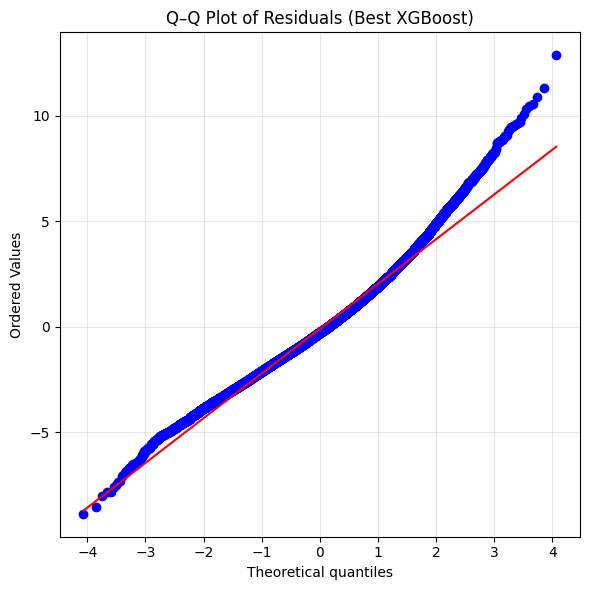

In [65]:
# Q–Q plot of residuals
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals (Best XGBoost)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## XGBoost — Feature Importance
Two complementary views:
- **Mean |SHAP Contribution|** — model-theoretic attribution in GRI units
- **XGBoost Gain** — split-weighted information gain


In [66]:
booster = xgb_h.get_booster()

dtest = xgb.DMatrix(X_test_6h, feature_names=list(X_test_6h.columns))
contribs = booster.predict(dtest, pred_contribs=True)  # (n_samples, n_features+1)

shap_cols = list(X_test_6h.columns) + ["BIAS"]
shap_imp  = (
    pd.DataFrame(contribs, columns=shap_cols)
    .drop(columns=["BIAS"])
    .abs()
    .mean()
    .sort_values(ascending=False)
)
shap_imp.name = "SHAP_mean_abs"

print("\nTop 20 features by mean |SHAP Contribution| (GRI units):")
for rank, (feat, val) in enumerate(shap_imp.head(20).items(), 1):
    print(f"  {rank:2d}. {feat:<45s} {val:.4f}")



Top 20 features by mean |SHAP Contribution| (GRI units):
   1. hour_sin                                      1.7941
   2. hour                                          0.4327
   3. WIND_TOTAL                                    0.4222
   4. IMPORTS                                       0.3447
   5. month_cos                                     0.2292
   6. year                                          0.2213
   7. dayofweek                                     0.2007
   8. IMPORTS_roll6_mean                            0.1347
   9. GAS                                           0.0981
  10. CLOUD_PCA_1                                   0.0961
  11. NUCLEAR                                       0.0890
  12. SOLAR_roll3_std                               0.0867
  13. hour_cos                                      0.0794
  14. dayofyear                                     0.0752
  15. IMPORTS_roll3_mean                            0.0645
  16. SOLAR                                         0.064

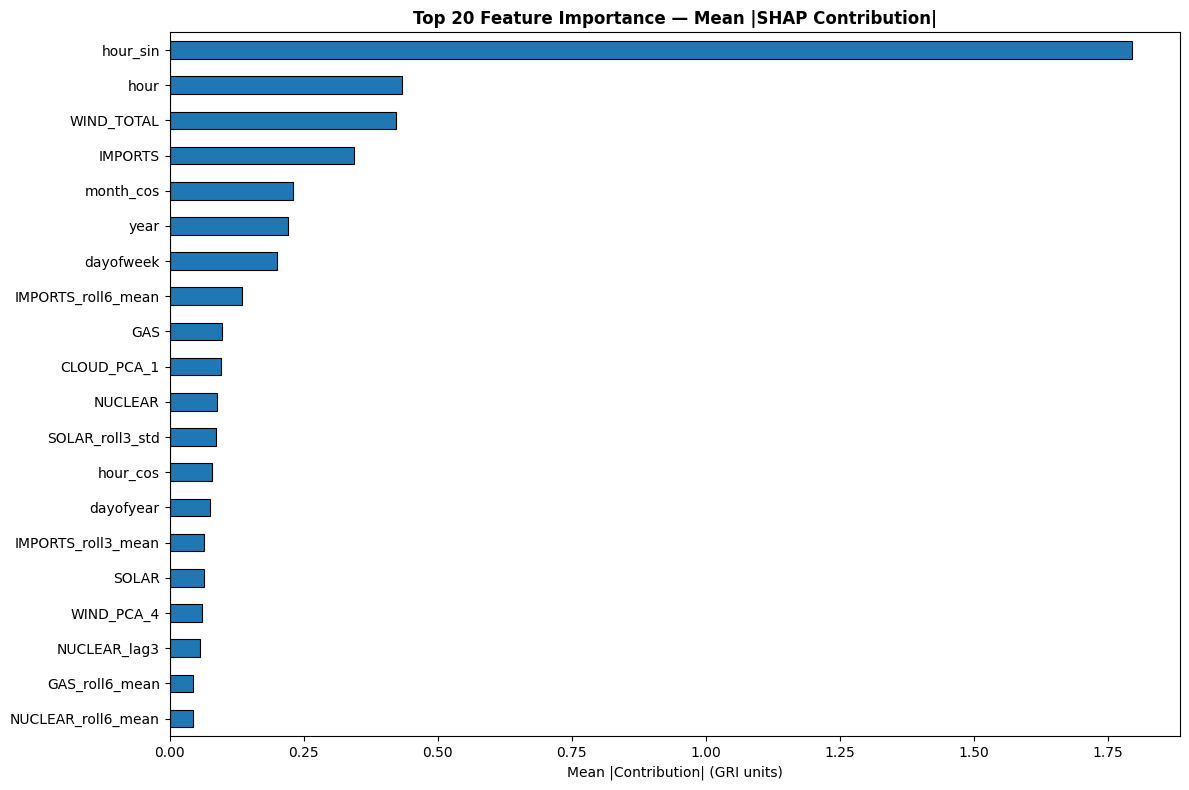

In [67]:
#  Top-20 SHAP bar chart
plt.figure(figsize=(12, 8))
shap_imp.head(20).iloc[::-1].plot(kind="barh", edgecolor="black", linewidth=0.8)
plt.title("Top 20 Feature Importance — Mean |SHAP Contribution|",
          fontweight="bold")
plt.xlabel("Mean |Contribution| (GRI units)")
plt.tight_layout()
plt.show()


In [68]:
# XGBoost Gain importance
gain_dict    = booster.get_score(importance_type="gain")
feature_names = list(X_test_6h.columns)

# Map f0-style keys to real names if needed
gain_mapped = {}
for fid, score in gain_dict.items():
    if fid.startswith("f") and fid[1:].isdigit():
        idx = int(fid[1:])
        if 0 <= idx < len(feature_names):
            gain_mapped[feature_names[idx]] = score
    elif fid in feature_names:
        gain_mapped[fid] = score
    else:
        print(f"⚠️  Unknown feature key from booster: {fid}")

xgb_gain = pd.Series(gain_mapped, name="XGB_gain")

#  Combined SHAP vs Gain comparison table
compare_imp = (
    pd.concat([shap_imp, xgb_gain], axis=1)
    .fillna(0)
    .assign(
        SHAP_rank    = lambda x: x["SHAP_mean_abs"].rank(ascending=False).astype(int),
        XGB_gain_rank = lambda x: x["XGB_gain"].rank(ascending=False).astype(int),
    )
    .sort_values("SHAP_mean_abs", ascending=False)
)

print("\nTop 20 features — SHAP vs XGBoost Gain comparison:")
display(compare_imp.head(20))



Top 20 features — SHAP vs XGBoost Gain comparison:


,SHAP_mean_abs,XGB_gain,SHAP_rank,XGB_gain_rank
hour_sin,1.794128,13000.841797,1,1
hour,0.432722,1217.248535,2,2
WIND_TOTAL,0.422207,1156.416260,3,3
IMPORTS,0.344722,542.572693,4,10
month_cos,0.229159,900.839783,5,5
year,0.221303,356.586090,6,15
dayofweek,0.200743,235.896851,7,27
IMPORTS_roll6_mean,0.134734,516.572876,8,12
GAS,0.098145,211.972137,9,34
CLOUD_PCA_1,0.096085,609.750000,10,8


##  SVM Benchmarks — LinearSVR & RBF-SVR

Trained on a **2-year subset** (2023-09-01 → 2025-08-31) to keep runtime feasible.

| Split | Period |
|-------|--------|
| Train | 2023-09-01 → 2024-12-31 |
| Test  | 2025-01-01 → 2025-08-31 |


In [69]:
# ============================================================
# SVM — data preparation (2-year subset)
# ============================================================
H = 12

df_svm_prep = df_feat2.copy()
df_svm_prep["DATETIME"] = pd.to_datetime(
    df_svm_prep["DATETIME"], utc=True, errors="coerce"
)

# Future target
df_svm_prep["GRI_t_plus_H"] = df_svm_prep["GRI"].shift(-H)
df_svm_prep = df_svm_prep.dropna(subset=["GRI_t_plus_H"]).reset_index(drop=True)

# Subset
subset_start = pd.Timestamp("2023-09-01", tz="UTC")
subset_end   = pd.Timestamp("2025-08-31", tz="UTC")
svm_end_train= pd.Timestamp("2024-12-31", tz="UTC")

mask_sub   = (df_svm_prep["DATETIME"] >= subset_start) & \
             (df_svm_prep["DATETIME"] <= subset_end)
df_svm_sub = df_svm_prep.loc[mask_sub].reset_index(drop=True)

train_idx_svm = (df_svm_sub["DATETIME"] >= subset_start) & \
                (df_svm_sub["DATETIME"] <= svm_end_train)
test_idx_svm  = (df_svm_sub["DATETIME"] >  svm_end_train) & \
                (df_svm_sub["DATETIME"] <= subset_end)

print(f"SVM subset: {len(df_svm_sub)} rows")
print(f"  Train: {train_idx_svm.sum()} | Test: {test_idx_svm.sum()}")

if train_idx_svm.sum() == 0 or test_idx_svm.sum() == 0:
    raise ValueError("Train or test set is empty. Check date boundaries.")

non_feat_svm = ["DATETIME", "GRI", "GRI_t_plus_H"]
feat_cols_svm = [c for c in df_svm_sub.columns if c not in non_feat_svm]

X_svm = df_svm_sub[feat_cols_svm]
y_svm = df_svm_sub["GRI_t_plus_H"]

X_train_svm, y_train_svm = X_svm[train_idx_svm], y_svm[train_idx_svm]
X_test_svm,  y_test_svm  = X_svm[test_idx_svm],  y_svm[test_idx_svm]

print(f"Feature count: {X_train_svm.shape[1]}")


SVM subset: 35041 rows
  Train: 23377 | Test: 11664
Feature count: 258


In [70]:
# Scale
sc_svm = StandardScaler()
X_train_scaled = sc_svm.fit_transform(X_train_svm)
X_test_scaled  = sc_svm.transform(X_test_svm)

def eval_regressor(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    r2     = r2_score(y_te, y_pred)
    mae    = mean_absolute_error(y_te, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    print(f"\n=== {name} ===")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    return r2, mae, rmse


In [71]:
# LinearSVR
lin_svr = LinearSVR(C=1.0, epsilon=0.0, max_iter=10000, random_state=RANDOM_STATE)
print("Training LinearSVR…")
lin_svr.fit(X_train_scaled, y_train_svm)
lin_metrics = eval_regressor(
    "LinearSVR (6h-ahead GRI, subset 2023-09-01→2025-08-31)",
    lin_svr, X_test_scaled, y_test_svm
)


Training LinearSVR…

=== LinearSVR (6h-ahead GRI, subset 2023-09-01→2025-08-31) ===
R²   : 0.5756
MAE  : 1.9331
RMSE : 2.4510


In [72]:
# SVR — RBF kernel
rbf_svr = SVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.1)
print("Training SVR (RBF kernel) — this may take several minutes…")
rbf_svr.fit(X_train_scaled, y_train_svm)
rbf_metrics = eval_regressor(
    "SVR RBF (6h-ahead GRI, subset 2023-09-01→2025-08-31)",
    rbf_svr, X_test_scaled, y_test_svm
)


Training SVR (RBF kernel) — this may take several minutes…

=== SVR RBF (6h-ahead GRI, subset 2023-09-01→2025-08-31) ===
R²   : 0.5395
MAE  : 1.9849
RMSE : 2.5531


## Final Model Comparison Summary

In [73]:
summary = pd.DataFrame({
    "Model": [
        "XGBoost Baseline (full period)",
        "XGBoost Best – Tuned (full period)",
        "LinearSVR (2-yr subset)",
        "SVR RBF  (2-yr subset)",
    ],
    "R²":   [r2_base,  r2_best,         lin_metrics[0], rbf_metrics[0]],
    "MAE":  [mae_base, mae_best,         lin_metrics[1], rbf_metrics[1]],
    "RMSE": [rmse_base, rmse_best,       lin_metrics[2], rbf_metrics[2]],
})
summary = summary.sort_values("R²", ascending=False).reset_index(drop=True)
summary.index += 1

print("=" * 60)
print("     MODEL PERFORMANCE COMPARISON — 6h-ahead GRI")
print("=" * 60)
display(summary)
summary.to_excel("model_comparison_summary.xlsx", index=False)
print("Saved to model_comparison_summary.xlsx")


     MODEL PERFORMANCE COMPARISON — 6h-ahead GRI


,Model,R²,MAE,RMSE
1,XGBoost Best – Tuned (full period),0.661958,1.665703,2.141704
2,XGBoost Baseline (full period),0.660731,1.668173,2.145589
3,LinearSVR (2-yr subset),0.575619,1.933058,2.450987
4,SVR RBF (2-yr subset),0.539529,1.984906,2.553081


Saved to model_comparison_summary.xlsx
